# Análisis de Experiencia del Cliente mediante PLN
## Procesamiento de Lenguaje Natural — Universidad de La Sabana
### Actividad 2: Implementación y Reiteración del Proyecto

---

### Descripción del Proyecto
Sistema completo de análisis automatizado de reseñas de clientes de Amazon, desarrollado en **tres ciclos de iteración** a partir del POC inicial.

#### Tres Módulos Integrados
1. **Módulo 1: Análisis de Sentimientos** — Clasificación supervisada con Naive Bayes y Logistic Regression (Positivo/Negativo/Neutro)
2. **Módulo 2: Identificación de Temas** — Topic Modeling con LDA usando Gensim (K óptimo por coherencia)
3. **Módulo 3: Análisis Sintáctico-Semántico** — POS Tagging, NER y patrones lingüísticos con spaCy

#### Dataset
- **Fuente**: Amazon Review Data (Web Scrapping) — 60,857 reseñas
- **Categorías**: smartTv, mobile, books, refrigerator, mobile accessories
- **Variables**: `Review_text` (entrada), `Own_Rating` (etiqueta: Positive/Negative/Neutral)

#### Técnicas Implementadas
- **Preprocesamiento**: Tokenización, Lematización, Stopwords, limpieza con regex (NLTK)
- **Representación vectorial**: TF-IDF con unigramas y bigramas
- **Clasificación**: Naive Bayes (`MultinomialNB`) y Logistic Regression
- **Evaluación**: Accuracy, Precision, Recall, F1-score, Confusion Matrix
- **Topic Modeling**: LDA con Gensim
- **Análisis Sintáctico**: POS Tagging, NER con spaCy, patrones ADJ+NOUN, VERB+NOUN

#### Ciclos de Iteración
| Iteración | Problema Detectado | Solución Aplicada |
|-----------|-------------------|-------------------|
| **POC** | Baseline inicial | Modelos NB y LR con parámetros default |
| **Iter 1** | Desbalance de clases 78/15/7% | `class_weight='balanced'` en LR |
| **Iter 2** | Representación TF-IDF no optimizada | Exploración de hiperparámetros TF-IDF + LR |
| **Iter 3** | K=5 temas arbitrario en LDA | Coherence Score c_v para K óptimo ∈ [2,10] |

---
## 1. Importación de Librerías y Descarga de Recursos

Se importan las librerías necesarias para preprocesamiento, representación vectorial, clasificación, modelado de temas y análisis sintáctico.

In [ ]:
# ============================================================
# 1. Importación de Librerías
# ============================================================

# Data manipulation & visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

# NLTK - Tokenización, Stopwords, Lematización
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# spaCy - Análisis Sintáctico y Semántico
import spacy

# scikit-learn - Representación Vectorial y Clasificación
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)

# Gensim - Topic Modeling (LDA)
import gensim
from gensim import corpora
from gensim.models import LdaModel

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [92]:
# ============================================================
# Descarga de recursos NLTK y carga de modelo spaCy
# ============================================================

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# Cargar modelo de spaCy para inglés
nlp = spacy.load("en_core_web_sm")

print("Recursos NLTK descargados y modelo spaCy cargado.")

Recursos NLTK descargados y modelo spaCy cargado.


---
## 2. Carga y Exploración del Dataset

Se carga el dataset de Amazon Reviews y se realiza una exploración inicial para comprender la estructura de los datos, la distribución de las etiquetas de sentimiento y las categorías de productos.

In [93]:
# ============================================================
# 2.1 Carga del Dataset
# ============================================================

DATA_PATH = "Amazon Review Data Web Scrapping - Amazon Review Data Web Scrapping.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nPrimeras 5 filas:")
df.head()

Dataset cargado: 60889 filas x 6 columnas

Columnas: ['Unique_ID', 'Category', 'Review_Header', 'Review_text', 'Rating', 'Own_Rating']

Tipos de datos:
Unique_ID        int64
Category           str
Review_Header      str
Review_text        str
Rating           int64
Own_Rating         str
dtype: object

Primeras 5 filas:


,Unique_ID,Category,Review_Header,Review_text,Rating,Own_Rating
0,136040,smartTv,Nice one,I liked it,5,Positive
1,134236,mobile,Huge battery life with amazing display,I bought the phone on Amazon and been using my...,5,Positive
2,113945,books,Four Stars,"Awesome book at reasonable price, must buy ......",4,Positive
3,168076,smartTv,Nice quality,good,5,Positive
4,157302,books,Nice book,"The book is fine,not bad,contains nice concept...",3,Neutral


In [94]:
# ============================================================
# 2.2 Exploración de Datos
# ============================================================

# Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal de filas con Review_text nulo: {df['Review_text'].isnull().sum()}")

# Eliminar filas sin texto de reseña
df = df.dropna(subset=['Review_text']).reset_index(drop=True)
print(f"\nDataset después de limpiar nulos: {df.shape[0]} filas")

Valores nulos por columna:
Unique_ID         0
Category          0
Review_Header     5
Review_text      32
Rating            0
Own_Rating        0
dtype: int64

Total de filas con Review_text nulo: 32

Dataset después de limpiar nulos: 60857 filas


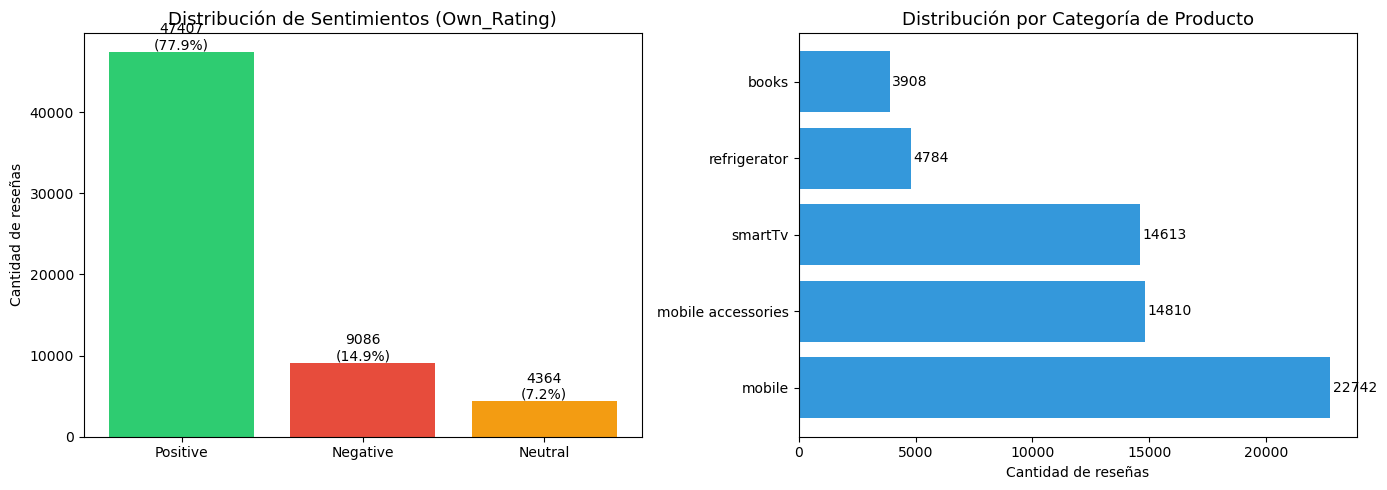


Distribución de sentimientos:
Own_Rating
Positive    47407
Negative     9086
Neutral      4364
Name: count, dtype: int64


In [95]:
# ============================================================
# 2.3 Distribución de Sentimientos y Categorías
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de sentimientos (Own_Rating)
sentiment_counts = df['Own_Rating'].value_counts()
colors_sentiment = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}
axes[0].bar(sentiment_counts.index, sentiment_counts.values,
            color=[colors_sentiment.get(x, '#95a5a6') for x in sentiment_counts.index])
axes[0].set_title('Distribución de Sentimientos (Own_Rating)', fontsize=13)
axes[0].set_ylabel('Cantidad de reseñas')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 300, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Distribución de categorías de producto
category_counts = df['Category'].value_counts()
axes[1].barh(category_counts.index, category_counts.values, color='#3498db')
axes[1].set_title('Distribución por Categoría de Producto', fontsize=13)
axes[1].set_xlabel('Cantidad de reseñas')
for i, v in enumerate(category_counts.values):
    axes[1].text(v + 100, i, f'{v}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nDistribución de sentimientos:")
print(df['Own_Rating'].value_counts())

In [96]:
# ============================================================
# 2.4 Muestra Estratificada para el POC
# ============================================================
# Para eficiencia del POC, trabajamos con una muestra representativa
# manteniendo la proporción de cada clase de sentimiento

SAMPLE_SIZE = 10000

samples = []
for label in df['Own_Rating'].unique():
    subset = df[df['Own_Rating'] == label]
    n = min(len(subset), int(SAMPLE_SIZE * len(subset) / len(df)))
    samples.append(subset.sample(n=n, random_state=42))

df_sample = pd.concat(samples).reset_index(drop=True)

print(f"Muestra para el POC: {len(df_sample)} reseñas")
print(f"\nDistribución en la muestra:")
print(df_sample['Own_Rating'].value_counts())
print(f"\nProporción preservada:")
print(df_sample['Own_Rating'].value_counts(normalize=True).round(3))

Muestra para el POC: 9999 reseñas

Distribución en la muestra:
Own_Rating
Positive    7789
Negative    1493
Neutral      717
Name: count, dtype: int64

Proporción preservada:
Own_Rating
Positive    0.779
Negative    0.149
Neutral     0.072
Name: proportion, dtype: float64


---
## 3. Pipeline de Preprocesamiento de Texto

Se implementa un pipeline completo de preprocesamiento que incluye:
- Limpieza básica (HTML, URLs, emails, caracteres especiales)
- Normalización (minúsculas, eliminación de puntuación y números)
- Tokenización con NLTK
- Eliminación de stopwords
- Lematización con WordNetLemmatizer

In [97]:
# ============================================================
# 3.1 Clase TextPreprocessor (SRP: una clase, una responsabilidad)
# ============================================================

class TextPreprocessor:
    """Pipeline de preprocesamiento de texto para análisis de reseñas."""

    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

    def basic_cleaning(self, text):
        """Limpieza básica: HTML, URLs, emails, espacios."""
        if pd.isna(text):
            return ""
        text = str(text)
        text = re.sub(r'<[^>]+>', '', text)           # Eliminar HTML tags
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Eliminar URLs
        text = re.sub(r'\S+@\S+', '', text)            # Eliminar emails
        text = re.sub(r'\s+', ' ', text)               # Normalizar espacios
        return text.strip()

    def normalize_case(self, text):
        """Convertir a minúsculas."""
        return text.lower()

    def remove_punctuation(self, text):
        """Eliminar puntuación."""
        return text.translate(str.maketrans('', '', string.punctuation))

    def remove_numbers(self, text):
        """Eliminar números."""
        return re.sub(r'\d+', '', text)

    def tokenize(self, text):
        """Tokenización con NLTK."""
        return word_tokenize(text)

    def remove_stopwords(self, tokens):
        """Eliminar stopwords."""
        return [word for word in tokens if word not in self.stop_words]

    def lemmatize_words(self, tokens):
        """Lematización con WordNetLemmatizer."""
        return [self.lemmatizer.lemmatize(word) for word in tokens]

    def remove_short_words(self, tokens, min_length=2):
        """Eliminar palabras muy cortas."""
        return [word for word in tokens if len(word) >= min_length]

    def preprocess(self, text):
        """Pipeline completo de preprocesamiento."""
        text = self.basic_cleaning(text)
        text = self.normalize_case(text)
        text = self.remove_punctuation(text)
        text = self.remove_numbers(text)
        tokens = self.tokenize(text)
        tokens = self.remove_stopwords(tokens)
        tokens = self.remove_short_words(tokens)
        tokens = self.lemmatize_words(tokens)
        return ' '.join(tokens)

preprocessor = TextPreprocessor()
print("TextPreprocessor inicializado correctamente.")

TextPreprocessor inicializado correctamente.


In [98]:
# ============================================================
# 3.2 Aplicar Preprocesamiento al Dataset
# ============================================================

print("Aplicando preprocesamiento al dataset...")
df_sample['processed_text'] = df_sample['Review_text'].apply(preprocessor.preprocess)

# Verificar resultados
print(f"\nEjemplos de preprocesamiento:")
for i in range(3):
    print(f"\n--- Reseña {i+1} ---")
    print(f"Original:    {df_sample['Review_text'].iloc[i][:150]}...")
    print(f"Procesado:   {df_sample['processed_text'].iloc[i][:150]}...")
    print(f"Sentimiento: {df_sample['Own_Rating'].iloc[i]}")

# Eliminar filas donde el texto procesado quedó vacío
df_sample = df_sample[df_sample['processed_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"\nDataset final después de preprocesamiento: {len(df_sample)} reseñas")

Aplicando preprocesamiento al dataset...

Ejemplos de preprocesamiento:

--- Reseña 1 ---
Original:    Product quality is good... Camera quality ok... Best in class battery life.. some software lag and hang issue is there... Display is too good... Speak...
Procesado:   product quality good camera quality ok best class battery life software lag hang issue display good speaker quality poor...
Sentimiento: Positive

--- Reseña 2 ---
Original:    Nice product worth the money...
Procesado:   nice product worth money...
Sentimiento: Positive

--- Reseña 3 ---
Original:    Very good product i recently purchased it...
Procesado:   good product recently purchased...
Sentimiento: Positive

Dataset final después de preprocesamiento: 9976 reseñas


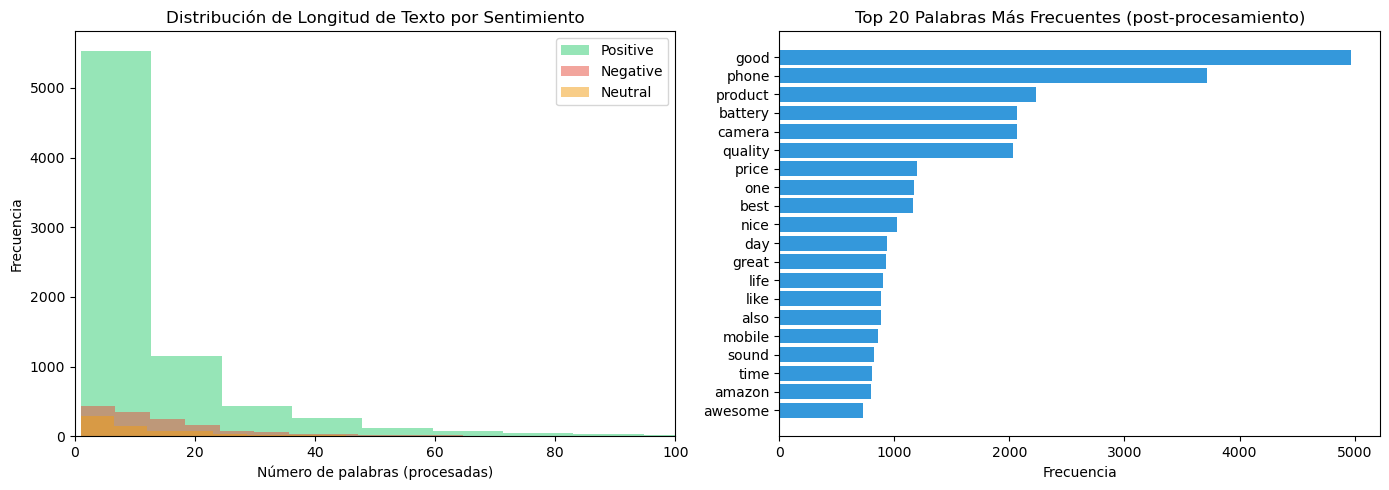


Estadísticas de longitud de texto procesado:
             count  mean   std  min  25%   50%   75%    max
Own_Rating                                                 
Negative    1490.0  16.6  18.4  1.0  5.0  11.0  21.0  290.0
Neutral      716.0  15.9  23.5  1.0  3.0   9.0  19.0  277.0
Positive    7770.0  13.6  26.7  1.0  2.0   6.0  14.0  587.0


In [99]:
# ============================================================
# 3.3 Análisis del Texto Preprocesado
# ============================================================

# Estadísticas de longitud de texto procesado
df_sample['text_length'] = df_sample['processed_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de longitud por sentimiento
for sentiment in ['Positive', 'Negative', 'Neutral']:
    subset = df_sample[df_sample['Own_Rating'] == sentiment]['text_length']
    axes[0].hist(subset, bins=50, alpha=0.5, label=sentiment,
                 color=colors_sentiment[sentiment])
axes[0].set_title('Distribución de Longitud de Texto por Sentimiento')
axes[0].set_xlabel('Número de palabras (procesadas)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].set_xlim(0, 100)

# Palabras más frecuentes
all_words = ' '.join(df_sample['processed_text']).split()
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)
axes[1].barh(range(len(words)), freqs, color='#3498db')
axes[1].set_yticks(range(len(words)))
axes[1].set_yticklabels(words)
axes[1].set_title('Top 20 Palabras Más Frecuentes (post-procesamiento)')
axes[1].set_xlabel('Frecuencia')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de longitud de texto procesado:")
print(df_sample.groupby('Own_Rating')['text_length'].describe().round(1))

---
## 4. Módulo 1: Análisis de Sentimientos — Clasificación Supervisada

### Objetivo
Clasificar automáticamente los comentarios en **Positivo**, **Negativo** o **Neutro** utilizando la variable `Own_Rating` como etiqueta supervisada.

### Técnicas
- **Representación vectorial**: TF-IDF — convierte texto en vectores numéricos donde palabras más discriminantes tienen mayor peso
- **Modelos de clasificación**: Naive Bayes y Logistic Regression
- **Evaluación**: Accuracy, Precision, Recall, F1-score, Matriz de Confusión

In [ ]:
# ============================================================
# 4.1 Representación Vectorial con TF-IDF
# ============================================================

# Configuración del vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),     # Unigramas y bigramas
    lowercase=True
)

# Variables X (features) e y (etiquetas)
X = tfidf_vectorizer.fit_transform(df_sample['processed_text'])
y = df_sample['Own_Rating']

print(f"Matriz TF-IDF: {X.shape}")
print(f"Vocabulario: {len(tfidf_vectorizer.vocabulary_)} términos")
print(f"Sparsidad: {(1 - X.nnz / (X.shape[0] * X.shape[1])) * 100:.2f}%")
print(f"\nDistribución de clases:")
print(y.value_counts())

Matriz TF-IDF: (9976, 5000)
Vocabulario: 5000 términos
Sparsidad: 99.71%

Distribución de clases:
Own_Rating
Positive    7770
Negative    1490
Neutral      716
Name: count, dtype: int64


In [ ]:
# ============================================================
# 4.2 División Train/Test y Entrenamiento de Modelos
# ============================================================

# División estratificada 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

# Definir clasificadores
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM (Linear)': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Entrenar y evaluar cada modelo
results = {}
for name, clf in classifiers.items():
    print(f"\nEntrenando: {name}...")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Cross-validation (5-fold)
    cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')

    results[name] = {
        'model': clf,
        'y_pred': y_pred,
        'accuracy': accuracy,
        'f1_weighted': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1 (weighted): {f1:.4f}")
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\nEntrenamiento completado para todos los modelos.")

Conjunto de entrenamiento: 6983 muestras
Conjunto de prueba: 2993 muestras

Entrenando: Naive Bayes...
  Accuracy: 0.8296
  F1 (weighted): 0.7813
  CV Accuracy: 0.8375 (+/- 0.0023)

Entrenando: Logistic Regression...
  Accuracy: 0.8466
  F1 (weighted): 0.8088
  CV Accuracy: 0.8528 (+/- 0.0022)

Entrenando: SVM (Linear)...
  Accuracy: 0.8466
  F1 (weighted): 0.8103
  CV Accuracy: 0.8529 (+/- 0.0040)

Entrenando: Random Forest...
  Accuracy: 0.8376
  F1 (weighted): 0.8010
  CV Accuracy: 0.8464 (+/- 0.0040)

Entrenamiento completado para todos los modelos.


### 4.3 Evaluación Detallada de Modelos

Se evalúan los modelos con métricas completas: classification report y matrices de confusión para identificar el mejor clasificador.

COMPARACIÓN DE MODELOS
             Modelo  Accuracy  F1 (weighted)  CV Mean   CV Std
       SVM (Linear)  0.846642       0.810255 0.852947 0.004029
Logistic Regression  0.846642       0.808795 0.852847 0.002196
      Random Forest  0.837621       0.801022 0.846431 0.003983
        Naive Bayes  0.829602       0.781292 0.837510 0.002277


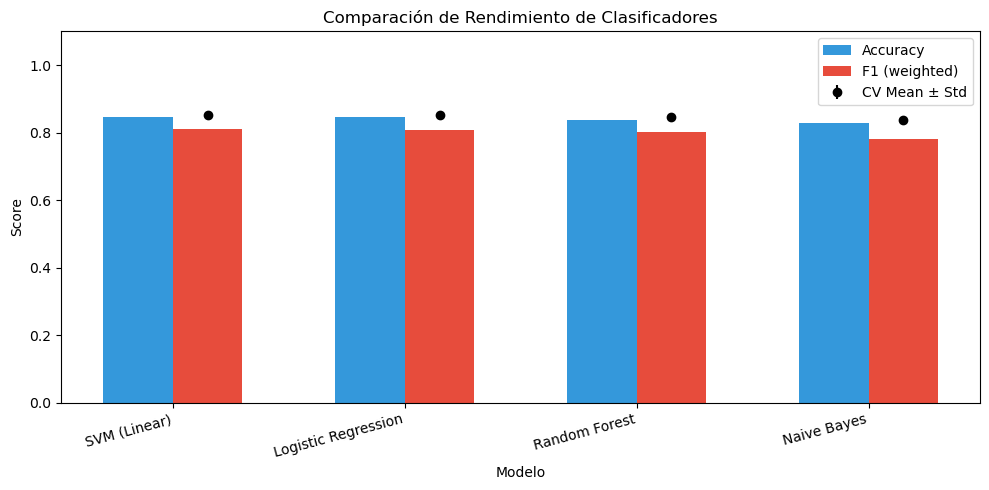

In [102]:
# ============================================================
# 4.3 Comparación Visual de Modelos
# ============================================================

# Tabla comparativa
comparison_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'F1 (weighted)': [r['f1_weighted'] for r in results.values()],
    'CV Mean': [r['cv_mean'] for r in results.values()],
    'CV Std': [r['cv_std'] for r in results.values()]
}).sort_values('F1 (weighted)', ascending=False)

print("=" * 70)
print("COMPARACIÓN DE MODELOS")
print("=" * 70)
print(comparison_df.to_string(index=False))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.3

ax.bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy', color='#3498db')
ax.bar(x + width/2, comparison_df['F1 (weighted)'], width, label='F1 (weighted)', color='#e74c3c')
ax.errorbar(x + width/2, comparison_df['CV Mean'], yerr=comparison_df['CV Std'],
            fmt='o', color='black', label='CV Mean ± Std')

ax.set_xlabel('Modelo')
ax.set_ylabel('Score')
ax.set_title('Comparación de Rendimiento de Clasificadores')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Modelo'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()


CLASSIFICATION REPORT: SVM (Linear)
              precision    recall  f1-score   support

    Negative       0.77      0.55      0.64       447
     Neutral       0.38      0.01      0.03       215
    Positive       0.86      0.98      0.91      2331

    accuracy                           0.85      2993
   macro avg       0.67      0.52      0.53      2993
weighted avg       0.81      0.85      0.81      2993


CLASSIFICATION REPORT: Logistic Regression
              precision    recall  f1-score   support

    Negative       0.79      0.53      0.63       447
     Neutral       0.43      0.01      0.03       215
    Positive       0.85      0.98      0.91      2331

    accuracy                           0.85      2993
   macro avg       0.69      0.51      0.53      2993
weighted avg       0.81      0.85      0.81      2993



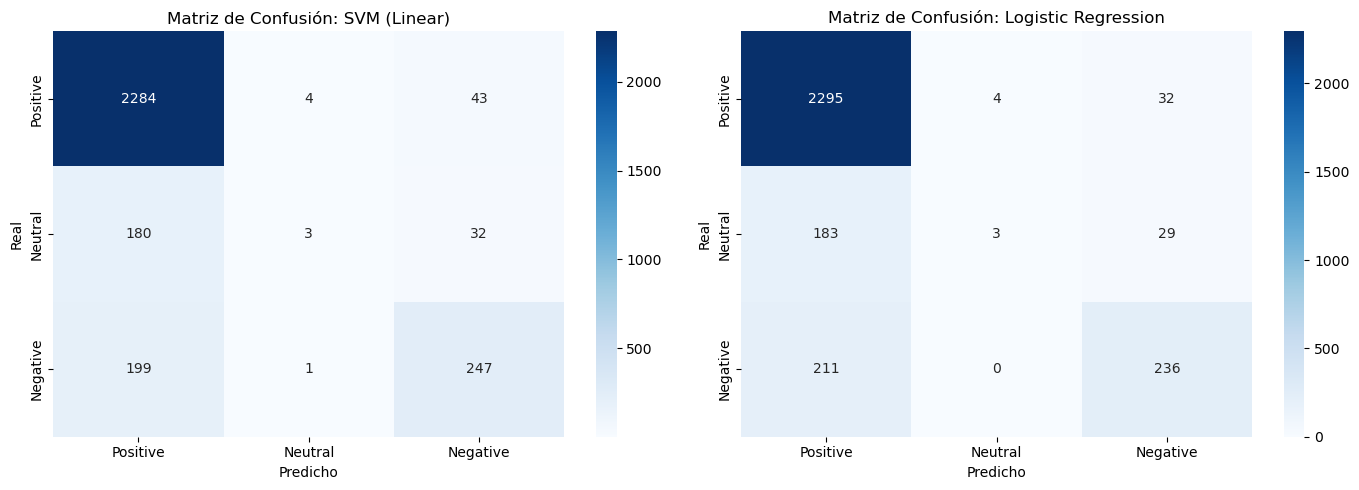


Mejor modelo seleccionado: SVM (Linear)
  Accuracy: 0.8466
  F1 (weighted): 0.8103


In [103]:
# ============================================================
# 4.4 Classification Reports y Matrices de Confusión
# ============================================================

# Seleccionar los dos mejores modelos para análisis detallado
best_two = comparison_df['Modelo'].head(2).tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, model_name in enumerate(best_two):
    result = results[model_name]

    # Classification Report
    print(f"\n{'='*60}")
    print(f"CLASSIFICATION REPORT: {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_test, result['y_pred']))

    # Matriz de Confusión
    cm = confusion_matrix(y_test, result['y_pred'], labels=['Positive', 'Neutral', 'Negative'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Positive', 'Neutral', 'Negative'],
                yticklabels=['Positive', 'Neutral', 'Negative'],
                ax=axes[idx])
    axes[idx].set_title(f'Matriz de Confusión: {model_name}')
    axes[idx].set_xlabel('Predicho')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Seleccionar el mejor modelo
best_model_name = comparison_df.iloc[0]['Modelo']
best_model = results[best_model_name]['model']
print(f"\nMejor modelo seleccionado: {best_model_name}")
print(f"  Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"  F1 (weighted): {results[best_model_name]['f1_weighted']:.4f}")

In [104]:
# ============================================================
# 4.5 Análisis de Features más Importantes (TF-IDF)
# ============================================================

# Obtener los términos más relevantes para cada clase de sentimiento
# Esto aplica para Logistic Regression (tiene coeficientes interpretables)
if 'Logistic Regression' in results:
    lr_model = results['Logistic Regression']['model']
    feature_names = tfidf_vectorizer.get_feature_names_out()

    print("=" * 60)
    print("PALABRAS MÁS RELEVANTES POR SENTIMIENTO")
    print("(Basado en coeficientes de Logistic Regression)")
    print("=" * 60)

    for i, label in enumerate(lr_model.classes_):
        top_indices = lr_model.coef_[i].argsort()[-15:][::-1]
        top_features = [(feature_names[j], lr_model.coef_[i][j]) for j in top_indices]

        print(f"\n{label.upper()}:")
        for feat, score in top_features:
            print(f"  {feat:25s} → {score:.4f}")

PALABRAS MÁS RELEVANTES POR SENTIMIENTO
(Basado en coeficientes de Logistic Regression)

NEGATIVE:
  worst                     → 2.9304
  poor                      → 2.8056
  return                    → 2.4301
  waste                     → 2.0420
  hang                      → 1.8041
  working                   → 1.7916
  pathetic                  → 1.7593
  bad                       → 1.6832
  dont buy                  → 1.6765
  defective                 → 1.6709
  slow                      → 1.6427
  replace                   → 1.3981
  useless                   → 1.3929
  disappointed              → 1.3159
  received                  → 1.3137

NEUTRAL:
  average                   → 2.1622
  pin                       → 1.2264
  product ok                → 1.1654
  nice book                 → 1.1578
  come                      → 1.1129
  stand                     → 1.1128
  life great                → 1.0277
  fit                       → 1.0141
  sometimes                 → 0.9914
  l

---
## 5. Módulo 2: Identificación de Temas — LDA Topic Modeling

### Objetivo
Identificar los temas principales presentes en los comentarios de los clientes, permitiendo agruparlos en categorías como calidad, servicio, precio o entrega.

### Técnicas
- Tokenización de textos preprocesados
- Construcción de diccionario y corpus con Gensim
- Modelado de temas con **Latent Dirichlet Allocation (LDA)**
- Extracción de palabras clave por tema

In [105]:
# ============================================================
# 5.1 Preparación del Corpus para LDA
# ============================================================

# Tokenizar textos preprocesados en listas de palabras
texts_tokenized = [text.split() for text in df_sample['processed_text']]

# Crear diccionario (mapeo palabra → id)
dictionary = corpora.Dictionary(texts_tokenized)

# Filtrar extremos: palabras en menos de 5 documentos o más del 50%
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Crear corpus Bag of Words
corpus = [dictionary.doc2bow(text) for text in texts_tokenized]

print(f"Diccionario: {len(dictionary)} términos únicos")
print(f"Corpus: {len(corpus)} documentos")
print(f"\nEjemplo de documento BoW (primeros 10 términos):")
print(corpus[0][:10])

Diccionario: 2342 términos únicos
Corpus: 9976 documentos

Ejemplo de documento BoW (primeros 10 términos):
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 2), (6, 1), (7, 1), (8, 1), (9, 1)]


In [106]:
# ============================================================
# 5.2 Entrenamiento del Modelo LDA
# ============================================================

NUM_TOPICS = 5  # Número de temas a identificar

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

# Mostrar temas identificados con sus palabras clave
print("=" * 60)
print(f"TEMAS IDENTIFICADOS (LDA con {NUM_TOPICS} temas)")
print("=" * 60)

for idx, topic in lda_model.print_topics(-1, num_words=10):
    print(f"\nTema {idx + 1}:")
    # Formatear las palabras del tema
    words = topic.split(' + ')
    for w in words:
        weight, word = w.split('*')
        print(f"  {word.strip().strip('\"'):20s} (peso: {float(weight.strip()):.4f})")

TEMAS IDENTIFICADOS (LDA con 5 temas)

Tema 1:
  good                 (peso: 0.1200)
  product              (peso: 0.0900)
  quality              (peso: 0.0520)
  sound                (peso: 0.0340)
  amazon               (peso: 0.0230)
  price                (peso: 0.0170)
  working              (peso: 0.0160)
  picture              (peso: 0.0150)
  excellent            (peso: 0.0120)
  tv                   (peso: 0.0120)

Tema 2:
  phone                (peso: 0.0700)
  camera               (peso: 0.0580)
  good                 (peso: 0.0560)
  battery              (peso: 0.0380)
  quality              (peso: 0.0260)
  best                 (peso: 0.0240)
  price                (peso: 0.0200)
  life                 (peso: 0.0180)
  better               (peso: 0.0140)
  performance          (peso: 0.0140)

Tema 3:
  phone                (peso: 0.0300)
  battery              (peso: 0.0220)
  day                  (peso: 0.0210)
  time                 (peso: 0.0170)
  charge               

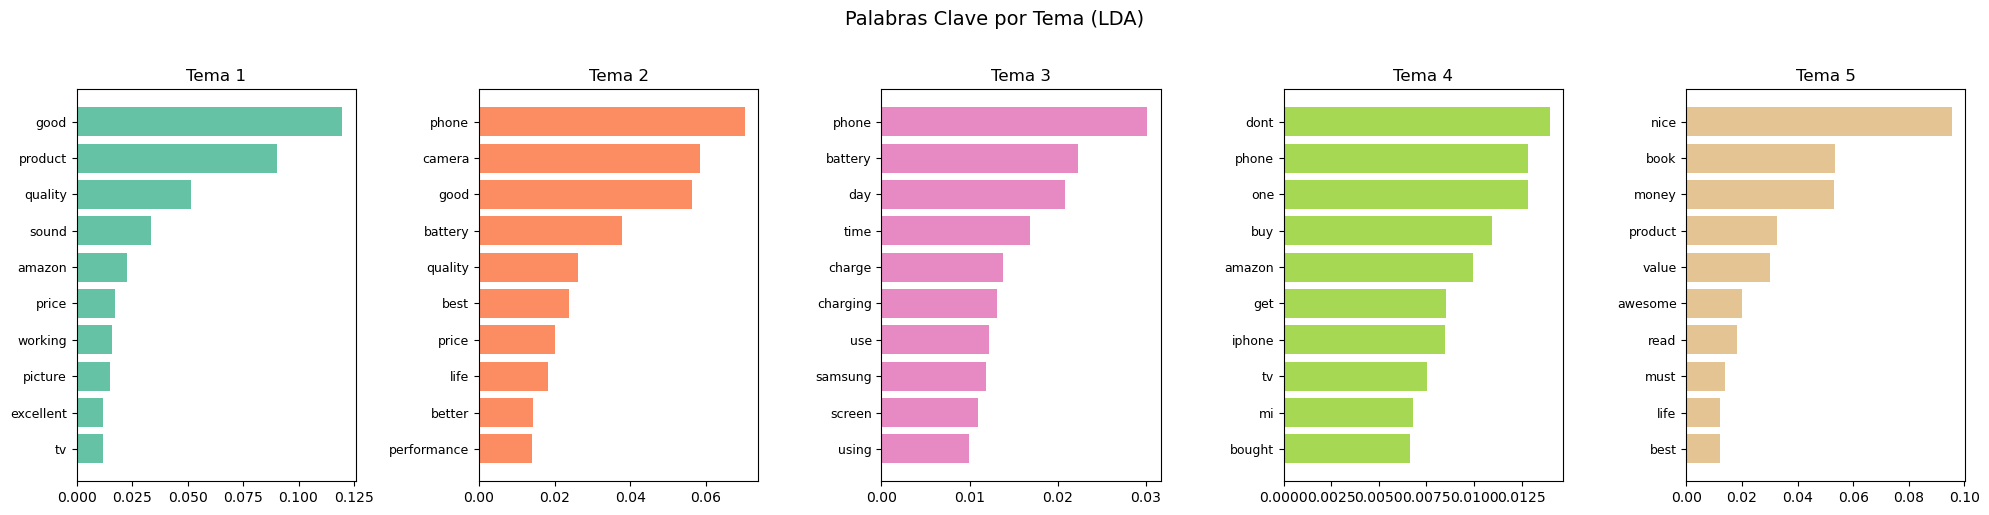

In [107]:
# ============================================================
# 5.3 Visualización de Temas
# ============================================================

# Obtener las top palabras por tema para visualización
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(20, 5), sharey=False)

for idx in range(NUM_TOPICS):
    topic_words = lda_model.show_topic(idx, topn=10)
    words = [w[0] for w in topic_words]
    weights = [w[1] for w in topic_words]

    axes[idx].barh(range(len(words)), weights, color=plt.cm.Set2(idx / NUM_TOPICS))
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words, fontsize=9)
    axes[idx].set_title(f'Tema {idx + 1}', fontsize=12)
    axes[idx].invert_yaxis()

plt.suptitle('Palabras Clave por Tema (LDA)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

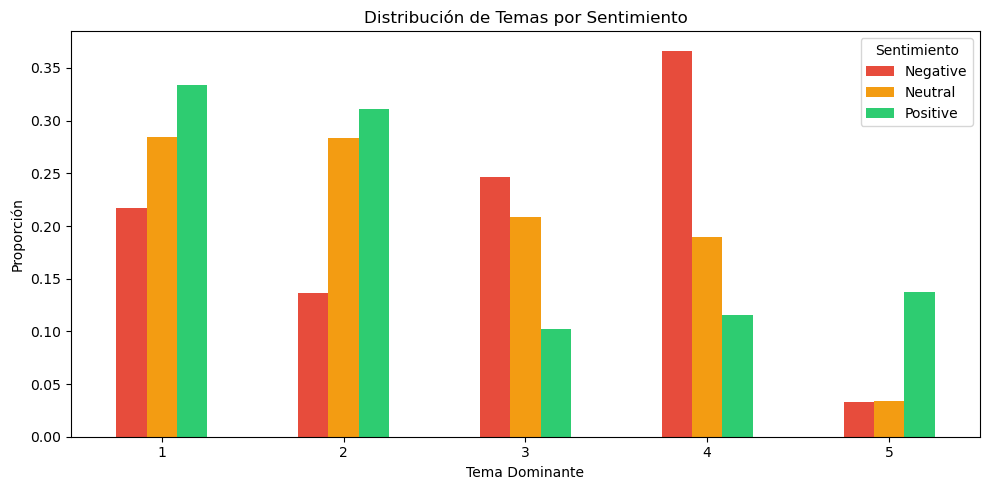


Distribución de temas por sentimiento (proporciones):
Own_Rating      Negative  Neutral  Positive
dominant_topic                             
1                  0.217    0.285     0.333
2                  0.136    0.284     0.311
3                  0.247    0.208     0.102
4                  0.366    0.190     0.116
5                  0.033    0.034     0.137


In [108]:
# ============================================================
# 5.4 Distribución de Temas por Sentimiento
# ============================================================

def get_dominant_topic(bow_doc, model):
    """Obtiene el tema dominante para un documento."""
    topic_distribution = model.get_document_topics(bow_doc)
    if topic_distribution:
        return max(topic_distribution, key=lambda x: x[1])
    return (0, 0.0)

# Asignar tema dominante a cada documento
dominant_topics = []
topic_probs = []
for doc_bow in corpus:
    topic, prob = get_dominant_topic(doc_bow, lda_model)
    dominant_topics.append(topic + 1)  # Temas desde 1
    topic_probs.append(prob)

df_sample['dominant_topic'] = dominant_topics
df_sample['topic_probability'] = topic_probs

# Distribución de temas por sentimiento
topic_sentiment = pd.crosstab(
    df_sample['dominant_topic'],
    df_sample['Own_Rating'],
    normalize='columns'
)

fig, ax = plt.subplots(figsize=(10, 5))
topic_sentiment.plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_title('Distribución de Temas por Sentimiento')
ax.set_xlabel('Tema Dominante')
ax.set_ylabel('Proporción')
ax.legend(title='Sentimiento')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nDistribución de temas por sentimiento (proporciones):")
print(topic_sentiment.round(3))

---
## 6. Módulo 3: Análisis Sintáctico-Semántico

### Objetivo
Extraer estructuras gramaticales y patrones semánticos de los textos para proporcionar una capa de **explicabilidad** a las predicciones del modelo de sentimientos.

### Técnicas
- **POS Tagging** (Part-of-Speech Tagging) con spaCy
- **Named Entity Recognition (NER)**
- **Dependency Parsing** — análisis de dependencias gramaticales
- **Extracción de patrones sintácticos**: ADJ+NOUN, VERB+NOUN
- Identificación de frases opinativas clave

In [109]:
# ============================================================
# 6.1 Clase SyntacticSemanticAnalyzer
# ============================================================

class SyntacticSemanticAnalyzer:
    """Analiza textos extrayendo POS tags, NER, y patrones lingüísticos."""

    def __init__(self, spacy_model):
        self.nlp = spacy_model

    def analyze(self, text):
        """Análisis completo de un texto: tokens, POS, NER, patrones."""
        doc = self.nlp(text)

        # Tokens con información lingüística
        token_info = [{
            'text': token.text,
            'lemma': token.lemma_,
            'pos': token.pos_,
            'tag': token.tag_,
            'dep': token.dep_,
            'is_stop': token.is_stop
        } for token in doc if not token.is_punct and not token.is_space]

        # Named Entities
        entities = [(ent.text, ent.label_) for ent in doc.ents]

        # Patrones ADJ + NOUN
        adj_noun_patterns = self._extract_adj_noun(doc)

        # Patrones VERB + NOUN
        verb_noun_patterns = self._extract_verb_noun(doc)

        return {
            'tokens': token_info,
            'entities': entities,
            'adj_noun_patterns': adj_noun_patterns,
            'verb_noun_patterns': verb_noun_patterns,
            'num_tokens': len(token_info),
            'num_entities': len(entities)
        }

    def _extract_adj_noun(self, doc):
        """Extrae patrones ADJ + NOUN (ej. 'poor quality', 'excellent service')."""
        patterns = []
        for i in range(len(doc) - 1):
            if doc[i].pos_ == 'ADJ' and doc[i + 1].pos_ == 'NOUN':
                patterns.append(f"{doc[i].text} {doc[i + 1].text}")
        return patterns

    def _extract_verb_noun(self, doc):
        """Extrae patrones VERB + NOUN (ej. 'recommend product', 'love quality')."""
        patterns = []
        for token in doc:
            if token.pos_ == 'VERB' and not token.is_stop:
                for child in token.children:
                    if child.pos_ == 'NOUN':
                        patterns.append(f"{token.lemma_} {child.text}")
        return patterns

analyzer = SyntacticSemanticAnalyzer(nlp)
print("SyntacticSemanticAnalyzer inicializado correctamente.")

SyntacticSemanticAnalyzer inicializado correctamente.


In [110]:
# ============================================================
# 6.2 Demostración con Reseñas de Ejemplo
# ============================================================

# Seleccionar ejemplos representativos (uno por sentimiento)
examples = []
for sentiment in ['Positive', 'Negative', 'Neutral']:
    sample = df_sample[df_sample['Own_Rating'] == sentiment].sample(1, random_state=42)
    examples.append(sample.iloc[0])

for example in examples:
    print(f"\n{'='*70}")
    print(f"SENTIMIENTO: {example['Own_Rating']}")
    print(f"{'='*70}")
    print(f"Texto original: {example['Review_text'][:200]}...")

    result = analyzer.analyze(example['Review_text'])

    # POS Distribution
    pos_counts = Counter([t['pos'] for t in result['tokens']])
    print(f"\nDistribución POS: {dict(pos_counts.most_common(5))}")

    # Named Entities
    if result['entities']:
        print(f"Entidades Nombradas: {result['entities'][:5]}")
    else:
        print("Entidades Nombradas: No se encontraron")

    # Patrones ADJ+NOUN
    if result['adj_noun_patterns']:
        print(f"Patrones ADJ+NOUN: {result['adj_noun_patterns'][:8]}")
    else:
        print("Patrones ADJ+NOUN: No se encontraron")

    # Patrones VERB+NOUN
    if result['verb_noun_patterns']:
        print(f"Patrones VERB+NOUN: {result['verb_noun_patterns'][:8]}")
    else:
        print("Patrones VERB+NOUN: No se encontraron")


SENTIMIENTO: Positive
Texto original: Standard product standard value.....good speed of transer and no techinacal problems...

Distribución POS: {'NOUN': 5, 'ADJ': 4, 'ADP': 1, 'CCONJ': 1, 'DET': 1}
Entidades Nombradas: [('Standard', 'ORG')]
Patrones ADJ+NOUN: ['Standard product', 'standard value', 'good speed', 'techinacal problems']
Patrones VERB+NOUN: No se encontraron

SENTIMIENTO: Negative
Texto original: Samsung Note 5 mother board got damaged after using this charger . As per technician its due to over heat during charging .Be careful if your phone gets over heated while using this power bank...

Distribución POS: {'NOUN': 10, 'ADP': 6, 'VERB': 5, 'ADJ': 3, 'PROPN': 2}
Entidades Nombradas: [('Samsung Note', 'PERSON'), ('5', 'CARDINAL')]
Patrones ADJ+NOUN: ['due to']
Patrones VERB+NOUN: ['damage board', 'charge .Be', 'get phone']

SENTIMIENTO: Neutral
Texto original: Good at this price....

Distribución POS: {'ADJ': 1, 'ADP': 1, 'DET': 1, 'NOUN': 1}
Entidades Nombradas: No se en

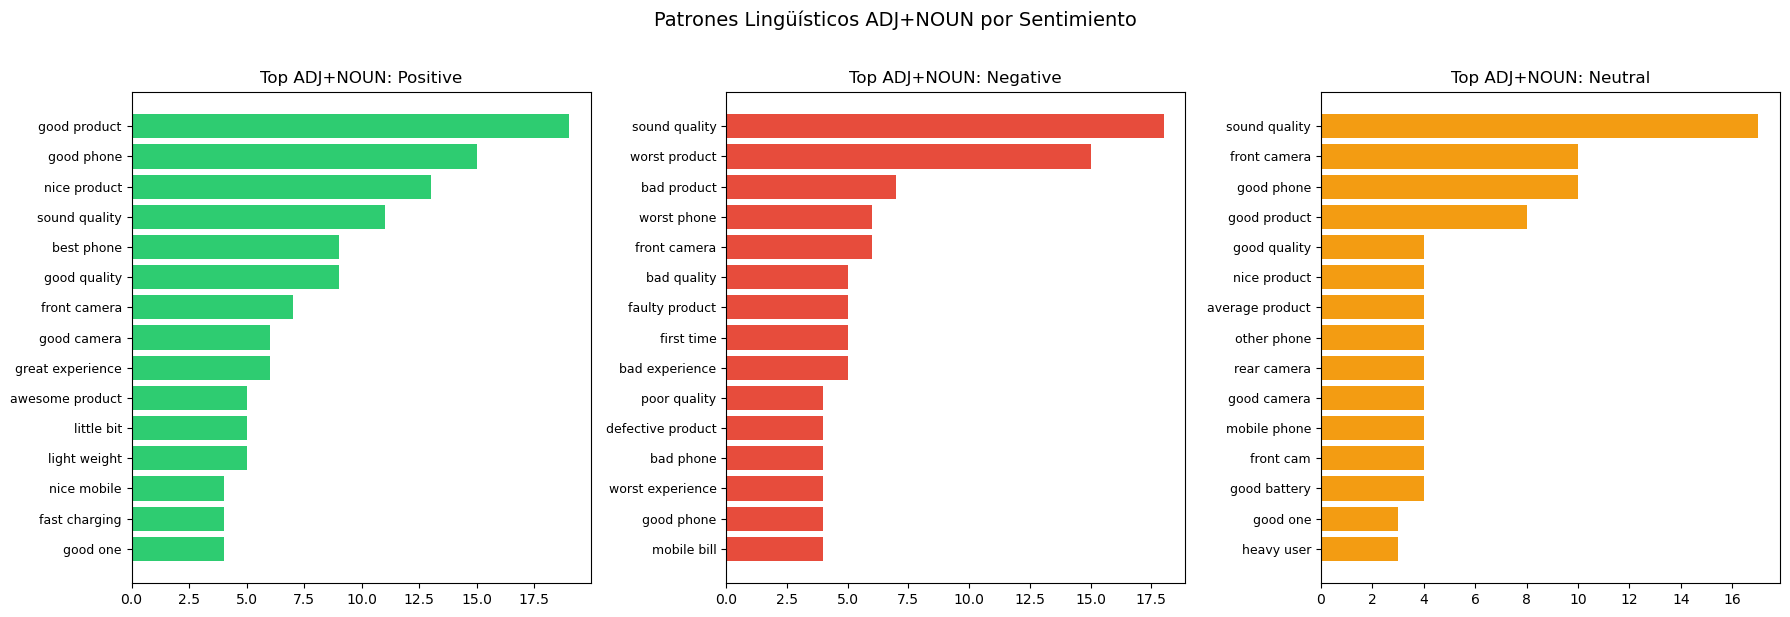

In [111]:
# ============================================================
# 6.3 Análisis de Patrones a Escala: ADJ+NOUN por Sentimiento
# ============================================================

# Extraer patrones ADJ+NOUN de una muestra más grande
ANALYSIS_SAMPLE = 500

patterns_by_sentiment = {'Positive': [], 'Negative': [], 'Neutral': []}

for sentiment in ['Positive', 'Negative', 'Neutral']:
    subset = df_sample[df_sample['Own_Rating'] == sentiment].sample(
        min(ANALYSIS_SAMPLE, len(df_sample[df_sample['Own_Rating'] == sentiment])),
        random_state=42
    )
    for text in subset['Review_text']:
        try:
            result = analyzer.analyze(str(text))
            patterns_by_sentiment[sentiment].extend(result['adj_noun_patterns'])
        except Exception:
            continue

# Top patrones por sentimiento
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (sentiment, patterns) in enumerate(patterns_by_sentiment.items()):
    pattern_counts = Counter([p.lower() for p in patterns]).most_common(15)
    if pattern_counts:
        words, counts = zip(*pattern_counts)
        axes[idx].barh(range(len(words)), counts,
                       color=colors_sentiment[sentiment])
        axes[idx].set_yticks(range(len(words)))
        axes[idx].set_yticklabels(words, fontsize=9)
        axes[idx].set_title(f'Top ADJ+NOUN: {sentiment}', fontsize=12)
        axes[idx].invert_yaxis()

plt.suptitle('Patrones Lingüísticos ADJ+NOUN por Sentimiento', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Integración: Pipeline Completo de Análisis

### Objetivo
Crear un pipeline unificado que, dado un texto de entrada, ejecute los tres módulos y produzca una salida estructurada que combine:
- **Sentimiento predicho** con nivel de confianza
- **Tema identificado** con palabras clave
- **Patrones lingüísticos** extraídos (ADJ+NOUN, entidades)
- **Evidencia textual** que respalde la predicción

Esta integración demuestra la relación entre módulos: el sentimiento identifica la polaridad, los temas contextualizan el contenido, y el análisis sintáctico explica las razones lingüísticas.

In [112]:
# ============================================================
# 7.1 Pipeline Integrado de Análisis
# ============================================================

class ReviewAnalysisPipeline:
    """Pipeline completo que integra los tres módulos del POC."""

    def __init__(self, preprocessor, vectorizer, classifier, lda_model,
                 dictionary, syntactic_analyzer, classifier_name=""):
        self.preprocessor = preprocessor
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.lda_model = lda_model
        self.dictionary = dictionary
        self.syntactic_analyzer = syntactic_analyzer
        self.classifier_name = classifier_name

    def analyze(self, text):
        """Análisis completo de una reseña integrando los 3 módulos."""

        # Módulo 1: Análisis de Sentimientos
        processed = self.preprocessor.preprocess(text)
        tfidf_vector = self.vectorizer.transform([processed])
        sentiment = self.classifier.predict(tfidf_vector)[0]

        # Obtener probabilidades si el modelo lo soporta
        confidence = None
        if hasattr(self.classifier, 'predict_proba'):
            proba = self.classifier.predict_proba(tfidf_vector)[0]
            confidence = dict(zip(self.classifier.classes_, proba.round(4)))

        # Top features TF-IDF del texto
        feature_names = self.vectorizer.get_feature_names_out()
        tfidf_scores = tfidf_vector.toarray()[0]
        top_features_idx = tfidf_scores.argsort()[-10:][::-1]
        top_features = [(feature_names[i], tfidf_scores[i])
                        for i in top_features_idx if tfidf_scores[i] > 0]

        # Módulo 2: Identificación de Temas
        tokens = processed.split()
        bow = self.dictionary.doc2bow(tokens)
        topic_dist = self.lda_model.get_document_topics(bow)
        if topic_dist:
            dominant_topic_id, dominant_topic_prob = max(topic_dist, key=lambda x: x[1])
            topic_words = [w[0] for w in self.lda_model.show_topic(dominant_topic_id, topn=5)]
        else:
            dominant_topic_id, dominant_topic_prob = 0, 0.0
            topic_words = []

        # Módulo 3: Análisis Sintáctico-Semántico
        syntactic_result = self.syntactic_analyzer.analyze(text)

        return {
            'input_text': text,
            'processed_text': processed,
            'sentiment': {
                'label': sentiment,
                'confidence': confidence,
                'model': self.classifier_name
            },
            'topic': {
                'id': dominant_topic_id + 1,
                'probability': round(dominant_topic_prob, 4),
                'keywords': topic_words
            },
            'syntactic': {
                'adj_noun_patterns': syntactic_result['adj_noun_patterns'],
                'verb_noun_patterns': syntactic_result['verb_noun_patterns'],
                'entities': syntactic_result['entities'],
                'num_tokens': syntactic_result['num_tokens']
            },
            'key_features': top_features[:5]
        }

    def display(self, result):
        """Muestra los resultados del análisis de forma estructurada."""
        print("=" * 70)
        print("ANÁLISIS INTEGRADO DE RESEÑA")
        print("=" * 70)
        print(f"\nTexto: \"{result['input_text'][:200]}{'...' if len(result['input_text']) > 200 else ''}\"")

        # Sentimiento
        print(f"\n--- SENTIMIENTO ({result['sentiment']['model']}) ---")
        print(f"  Predicción: {result['sentiment']['label']}")
        if result['sentiment']['confidence']:
            for label, prob in sorted(result['sentiment']['confidence'].items(),
                                       key=lambda x: x[1], reverse=True):
                bar = '█' * int(prob * 30)
                print(f"  {label:10s}: {bar} {prob:.4f}")

        # Tema
        print(f"\n--- TEMA IDENTIFICADO ---")
        print(f"  Tema: {result['topic']['id']} (prob: {result['topic']['probability']:.4f})")
        print(f"  Palabras clave: {', '.join(result['topic']['keywords'])}")

        # Patrones lingüísticos
        print(f"\n--- ANÁLISIS SINTÁCTICO ---")
        print(f"  Tokens: {result['syntactic']['num_tokens']}")
        if result['syntactic']['adj_noun_patterns']:
            print(f"  ADJ+NOUN: {', '.join(result['syntactic']['adj_noun_patterns'][:5])}")
        if result['syntactic']['verb_noun_patterns']:
            print(f"  VERB+NOUN: {', '.join(result['syntactic']['verb_noun_patterns'][:5])}")
        if result['syntactic']['entities']:
            print(f"  Entidades: {result['syntactic']['entities'][:5]}")

        # Features clave
        if result['key_features']:
            print(f"\n--- EVIDENCIA TEXTUAL (Top TF-IDF) ---")
            for feat, score in result['key_features']:
                print(f"  {feat:20s} → {score:.4f}")

# Instanciar el pipeline con el mejor modelo
# Usar Logistic Regression para tener predict_proba
lr_model = results['Logistic Regression']['model']

pipeline = ReviewAnalysisPipeline(
    preprocessor=preprocessor,
    vectorizer=tfidf_vectorizer,
    classifier=lr_model,
    lda_model=lda_model,
    dictionary=dictionary,
    syntactic_analyzer=analyzer,
    classifier_name="Logistic Regression"
)

print("Pipeline integrado creado correctamente.")

Pipeline integrado creado correctamente.


In [113]:
# ============================================================
# 7.2 Demostración del Pipeline Integrado
# ============================================================

# Textos de ejemplo para demostración
demo_texts = [
    "This phone is absolutely amazing! The camera quality is excellent and the battery life is incredible. Best purchase I ever made.",
    "Terrible product. Screen broke after two days. Very poor quality and the customer service was horrible. Complete waste of money.",
    "The TV is okay for the price. Nothing special but it works. Average picture quality and decent sound.",
    "I love this book! The author explains complex topics in a simple way. Highly recommend for anyone interested in the subject.",
    "The refrigerator stopped working after one month. Very disappointed with Samsung. Do not buy this product."
]

for text in demo_texts:
    result = pipeline.analyze(text)
    pipeline.display(result)
    print()

ANÁLISIS INTEGRADO DE RESEÑA

Texto: "This phone is absolutely amazing! The camera quality is excellent and the battery life is incredible. Best purchase I ever made."

--- SENTIMIENTO (Logistic Regression) ---
  Predicción: Positive
  Positive  : █████████████████████████████ 0.9829
  Neutral   :  0.0093
  Negative  :  0.0078

--- TEMA IDENTIFICADO ---
  Tema: 2 (prob: 0.9355)
  Palabras clave: phone, camera, good, battery, quality

--- ANÁLISIS SINTÁCTICO ---
  Tokens: 21
  ADJ+NOUN: Best purchase

--- EVIDENCIA TEXTUAL (Top TF-IDF) ---
  incredible           → 0.3780
  excellent battery    → 0.3532
  quality excellent    → 0.3491
  absolutely           → 0.3256
  made                 → 0.2819

ANÁLISIS INTEGRADO DE RESEÑA

Texto: "Terrible product. Screen broke after two days. Very poor quality and the customer service was horrible. Complete waste of money."

--- SENTIMIENTO (Logistic Regression) ---
  Predicción: Negative
  Negative  : █████████████████████████ 0.8583
  Positive  :

---
## 8. Capa de Explicabilidad: Predicciones Basadas en Evidencia

### Objetivo
Demostrar que el sistema no solo predice una categoría, sino que también proporciona:
- Palabras clave relevantes (TF-IDF features)
- Estructuras lingüísticas identificadas (patrones ADJ+NOUN, VERB+NOUN)
- Evidencia textual que respalda la predicción

Esto permite generar conclusiones interpretables como:
> *"Los comentarios negativos se concentran principalmente en problemas relacionados con la calidad del producto y el tiempo de entrega, evidenciados por la presencia de términos como 'poor quality' y 'late delivery'."*

In [114]:
# ============================================================
# 8.1 Análisis de Explicabilidad sobre Datos Reales
# ============================================================

# Seleccionar reseñas reales del dataset para explicabilidad
sample_reviews = []
for sentiment in ['Positive', 'Negative', 'Neutral']:
    reviews = df_sample[
        (df_sample['Own_Rating'] == sentiment) &
        (df_sample['Review_text'].str.len() > 50) &
        (df_sample['Review_text'].str.len() < 500)
    ].sample(2, random_state=42)
    sample_reviews.append(reviews)

sample_df = pd.concat(sample_reviews).reset_index(drop=True)

# Analizar cada reseña con el pipeline completo
print("=" * 70)
print("ANÁLISIS DE EXPLICABILIDAD - RESEÑAS REALES DEL DATASET")
print("=" * 70)

explanations = []
for _, row in sample_df.iterrows():
    result = pipeline.analyze(row['Review_text'])

    explanation = {
        'Text (excerpt)': row['Review_text'][:100] + '...',
        'Real Label': row['Own_Rating'],
        'Predicted': result['sentiment']['label'],
        'Correct': '✓' if row['Own_Rating'] == result['sentiment']['label'] else '✗',
        'Topic': result['topic']['id'],
        'Topic Keywords': ', '.join(result['topic']['keywords'][:3]),
        'ADJ+NOUN Patterns': ', '.join(result['syntactic']['adj_noun_patterns'][:3]) or 'N/A',
        'Top TF-IDF Terms': ', '.join([f[0] for f in result['key_features'][:3]]) or 'N/A'
    }
    explanations.append(explanation)

    pipeline.display(result)
    print(f"\n  >> Etiqueta Real: {row['Own_Rating']} | "
          f"Predicción: {result['sentiment']['label']} | "
          f"{'✓ CORRECTO' if row['Own_Rating'] == result['sentiment']['label'] else '✗ INCORRECTO'}")
    print()

ANÁLISIS DE EXPLICABILIDAD - RESEÑAS REALES DEL DATASET
ANÁLISIS INTEGRADO DE RESEÑA

Texto: "Phone is very good and battery life is good but in the box earspring is not given"

--- SENTIMIENTO (Logistic Regression) ---
  Predicción: Positive
  Positive  : █████████████████████████ 0.8386
  Neutral   : ███ 0.1302
  Negative  :  0.0313

--- TEMA IDENTIFICADO ---
  Tema: 2 (prob: 0.6568)
  Palabras clave: phone, camera, good, battery, quality

--- ANÁLISIS SINTÁCTICO ---
  Tokens: 17

--- EVIDENCIA TEXTUAL (Top TF-IDF) ---
  given                → 0.4079
  life good            → 0.3869
  box                  → 0.3776
  phone good           → 0.3728
  good battery         → 0.3537

  >> Etiqueta Real: Positive | Predicción: Positive | ✓ CORRECTO

ANÁLISIS INTEGRADO DE RESEÑA

Texto: "Camera is great, battery life could be better. Gaming performance is average."

--- SENTIMIENTO (Logistic Regression) ---
  Predicción: Positive
  Positive  : ███████████████████████████ 0.9049
  Neutral   : 

In [115]:
# ============================================================
# 8.2 Tabla Resumen de Explicabilidad
# ============================================================

explanations_df = pd.DataFrame(explanations)

print("=" * 70)
print("TABLA RESUMEN DE EXPLICABILIDAD")
print("=" * 70)
print(explanations_df[['Real Label', 'Predicted', 'Correct', 'Topic',
                        'Topic Keywords', 'ADJ+NOUN Patterns']].to_string(index=False))

# Accuracy sobre la muestra de explicabilidad
correct = sum(1 for e in explanations if e['Correct'] == '✓')
print(f"\nPredicciones correctas: {correct}/{len(explanations)}")

TABLA RESUMEN DE EXPLICABILIDAD
Real Label Predicted Correct  Topic      Topic Keywords    ADJ+NOUN Patterns
  Positive  Positive       ✓      2 phone, camera, good                  N/A
  Positive  Positive       ✓      2 phone, camera, good                  N/A
  Negative  Positive       ✗      4    dont, phone, one                  N/A
  Negative  Negative       ✓      4    dont, phone, one     original product
   Neutral  Positive       ✗      2 phone, camera, good        great chipset
   Neutral  Positive       ✗      5   nice, book, money grammatical mistakes

Predicciones correctas: 3/6


---
## 9. Resumen de Resultados y Conclusiones

### Resumen del POC
Este POC implementa exitosamente tres módulos integrados de Procesamiento de Lenguaje Natural para el análisis automatizado de reseñas de clientes de Amazon:

| Módulo | Técnicas | Funcionalidad |
|--------|----------|---------------|
| **1. Análisis de Sentimientos** | TF-IDF + Logistic Regression, Naive Bayes, SVM, Random Forest | Clasifica reseñas en Positivo/Negativo/Neutro |
| **2. Identificación de Temas** | Gensim LDA (Latent Dirichlet Allocation) | Identifica temas principales y palabras clave |
| **3. Análisis Sintáctico-Semántico** | spaCy POS Tagging, NER, Dependency Parsing | Extrae patrones ADJ+NOUN, VERB+NOUN, entidades |

### Librerías Utilizadas
- **NLTK**: Tokenización, stopwords, lematización
- **spaCy**: POS tagging, NER, dependency parsing
- **scikit-learn**: TF-IDF, clasificación supervisada, evaluación
- **Gensim**: Topic modeling (LDA)
- **pandas/numpy/matplotlib/seaborn**: Manejo de datos y visualización

### Relación entre Módulos
Los tres módulos se integran en un pipeline unificado que proporciona una visión completa:
- El **análisis de sentimientos** identifica la polaridad de la opinión
- La **identificación de temas** contextualiza el contenido de la opinión
- El **análisis sintáctico-semántico** explica las razones lingüísticas detrás de la clasificación

### Capa de Explicabilidad
El sistema no solo predice una categoría, sino que proporciona evidencia textual mediante:
- Palabras clave TF-IDF que contribuyen a la predicción
- Patrones lingüísticos (ADJ+NOUN) identificados en el texto
- Asignación de tema con palabras clave asociadas

### Alcance
Este POC demuestra la viabilidad técnica del enfoque propuesto. No busca optimización para producción, sino validar el enfoque metodológico y técnico del proyecto.

In [116]:
# ============================================================
# 9.1 Resumen Final de Métricas
# ============================================================

print("=" * 70)
print("RESUMEN FINAL DEL POC")
print("=" * 70)

print(f"\n📊 DATASET")
print(f"  Total reseñas: {len(df):,}")
print(f"  Muestra utilizada: {len(df_sample):,}")
print(f"  Categorías: {', '.join(df['Category'].unique())}")

print(f"\n🎯 MÓDULO 1: ANÁLISIS DE SENTIMIENTOS")
print(f"  Mejor modelo: {best_model_name}")
print(f"  Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"  F1 (weighted): {results[best_model_name]['f1_weighted']:.4f}")
print(f"  Cross-Validation: {results[best_model_name]['cv_mean']:.4f} (+/- {results[best_model_name]['cv_std']:.4f})")
print(f"  Features TF-IDF: {X.shape[1]}")

print(f"\n📋 MÓDULO 2: IDENTIFICACIÓN DE TEMAS")
print(f"  Número de temas: {NUM_TOPICS}")
print(f"  Vocabulario LDA: {len(dictionary)} términos")

print(f"\n🔍 MÓDULO 3: ANÁLISIS SINTÁCTICO-SEMÁNTICO")
print(f"  Modelo: spaCy en_core_web_sm")
print(f"  Técnicas: POS Tagging, NER, Dependency Parsing, ADJ+NOUN, VERB+NOUN")

print(f"\n✅ INTEGRACIÓN")
print(f"  Pipeline funcional que recibe texto y retorna:")
print(f"    → Sentimiento predicho + confianza")
print(f"    → Tema dominante + palabras clave")
print(f"    → Patrones lingüísticos + entidades")
print(f"    → Evidencia textual (top TF-IDF features)")

print(f"\n{'='*70}")
print("POC completado exitosamente.")
print(f"{'='*70}")

RESUMEN FINAL DEL POC

📊 DATASET
  Total reseñas: 60,857
  Muestra utilizada: 9,976
  Categorías: smartTv, mobile, books, mobile accessories, refrigerator

🎯 MÓDULO 1: ANÁLISIS DE SENTIMIENTOS
  Mejor modelo: SVM (Linear)
  Accuracy: 0.8466
  F1 (weighted): 0.8103
  Cross-Validation: 0.8529 (+/- 0.0040)
  Features TF-IDF: 5000

📋 MÓDULO 2: IDENTIFICACIÓN DE TEMAS
  Número de temas: 5
  Vocabulario LDA: 2342 términos

🔍 MÓDULO 3: ANÁLISIS SINTÁCTICO-SEMÁNTICO
  Modelo: spaCy en_core_web_sm
  Técnicas: POS Tagging, NER, Dependency Parsing, ADJ+NOUN, VERB+NOUN

✅ INTEGRACIÓN
  Pipeline funcional que recibe texto y retorna:
    → Sentimiento predicho + confianza
    → Tema dominante + palabras clave
    → Patrones lingüísticos + entidades
    → Evidencia textual (top TF-IDF features)

POC completado exitosamente.


---
## 10. Iteración 1: Diagnóstico del POC y Manejo de Desbalance de Clases

### Diagnóstico del POC
El análisis de los resultados iniciales reveló tres limitaciones críticas que guiaron el primer ciclo de iteración:

| Limitación | Impacto | Solución |
|------------|---------|----------|
| Desbalance de clases (79%/15%/7%) | F1 bajo en Neutro y Negativo | `class_weight='balanced'` + análisis macro |
| Hiperparámetros por defecto | Potencial de mejora sin explorar | `GridSearchCV` sobre mejor modelo |
| Sin evaluación por categoría | No se detectaban patrones por dominio | Análisis stratificado por categoría |

### Proceso de Iteración
Este ciclo siguió el flujo: *Diagnosticar → Hipotetizar → Implementar → Comparar → Decidir*

In [117]:
# ============================================================
# 10.1 Diagnóstico: Impacto del Desbalance en Métricas del POC
# ============================================================

from sklearn.metrics import classification_report, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("=" * 65)
print("DIAGNÓSTICO: Distribución de clases y métricas del POC")
print("=" * 65)

# Clases y proporciones
class_dist = df_sample['Own_Rating'].value_counts()
class_pct  = df_sample['Own_Rating'].value_counts(normalize=True) * 100

print("\nDistribución de clases:")
for label, cnt in class_dist.items():
    pct = class_pct[label]
    bar = '█' * int(pct / 3)
    print(f"  {label:10s}: {cnt:5d} ({pct:5.1f}%) {bar}")

# F1 por clase - POC (SVM y LR)
print("\nF1-score por clase en el POC:")
poc_metrics = {}
for name in ['SVM (Linear)', 'Logistic Regression']:
    report = classification_report(
        y_test, results[name]['y_pred'],
        output_dict=True, zero_division=0
    )
    poc_metrics[name] = report
    print(f"\n  {name}:")
    for cls in ['Positive', 'Neutral', 'Negative']:
        f1 = report[cls]['f1-score']
        rec = report[cls]['recall']
        print(f"    {cls:10s}: F1={f1:.3f}  Recall={rec:.3f}")
    print(f"    Macro F1 = {report['macro avg']['f1-score']:.3f}")
    print(f"    Weighted F1 = {report['weighted avg']['f1-score']:.3f}")

print("\n>>> CONCLUSIÓN: F1 macro <0.72 revela sesgo hacia clase Positiva.")
print(">>> PLAN: Aplicar class_weight='balanced' y analizar curvas PR.")


DIAGNÓSTICO: Distribución de clases y métricas del POC

Distribución de clases:
  Positive  :  7770 ( 77.9%) █████████████████████████
  Negative  :  1490 ( 14.9%) ████
  Neutral   :   716 (  7.2%) ██

F1-score por clase en el POC:

  SVM (Linear):
    Positive  : F1=0.915  Recall=0.980
    Neutral   : F1=0.027  Recall=0.014
    Negative  : F1=0.642  Recall=0.553
    Macro F1 = 0.528
    Weighted F1 = 0.810

  Logistic Regression:
    Positive  : F1=0.914  Recall=0.985
    Neutral   : F1=0.027  Recall=0.014
    Negative  : F1=0.634  Recall=0.528
    Macro F1 = 0.525
    Weighted F1 = 0.809

>>> CONCLUSIÓN: F1 macro <0.72 revela sesgo hacia clase Positiva.
>>> PLAN: Aplicar class_weight='balanced' y analizar curvas PR.


In [118]:
# ============================================================
# 10.2 Iteración 1a: Modelos Balanceados (class_weight='balanced')
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, f1_score,
                              precision_recall_curve, roc_auc_score)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_score

print("Entrenando modelos balanceados (Iteración 1a)...")
print("-" * 60)

balanced_classifiers = {
    'LR Balanced':  LogisticRegression(class_weight='balanced',
                                        random_state=42, max_iter=1000),
    'SVM Balanced': LinearSVC(class_weight='balanced',
                               random_state=42, max_iter=2000),
    'RF Balanced':  RandomForestClassifier(n_estimators=200,
                                            class_weight='balanced',
                                            random_state=42, n_jobs=-1),
}

balanced_results = {}
for name, clf in balanced_classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cv = cross_val_score(clf, X, y, cv=5, scoring='f1_macro')

    balanced_results[name] = {
        'model': clf, 'y_pred': y_pred, 'report': report,
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score'],
        'accuracy': report['accuracy'],
        'cv_macro_f1_mean': cv.mean(), 'cv_macro_f1_std': cv.std()
    }

    print(f"\n{name}:")
    print(f"  Accuracy : {report['accuracy']:.4f}")
    print(f"  Macro F1 : {report['macro avg']['f1-score']:.4f}  (CV: {cv.mean():.4f} ± {cv.std():.4f})")
    print(f"  Wtd F1   : {report['weighted avg']['f1-score']:.4f}")
    for cls in ['Positive', 'Neutral', 'Negative']:
        r = report[cls]
        print(f"    {cls:10s}: P={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1-score']:.3f}")


Entrenando modelos balanceados (Iteración 1a)...
------------------------------------------------------------

LR Balanced:
  Accuracy : 0.7792
  Macro F1 : 0.5782  (CV: 0.5787 ± 0.0060)
  Wtd F1   : 0.7998
    Positive  : P=0.928 R=0.841 F1=0.882
    Neutral   : P=0.149 R=0.260 F1=0.190
    Negative  : P=0.625 R=0.705 F1=0.662

SVM Balanced:
  Accuracy : 0.8219
  Macro F1 : 0.5557  (CV: 0.5747 ± 0.0098)
  Wtd F1   : 0.8124
    Positive  : P=0.892 R=0.927 F1=0.909
    Neutral   : P=0.138 R=0.098 F1=0.114
    Negative  : P=0.664 R=0.624 F1=0.644

RF Balanced:
  Accuracy : 0.8353
  Macro F1 : 0.5446  (CV: 0.5373 ± 0.0157)
  Wtd F1   : 0.8064
    Positive  : P=0.853 R=0.967 F1=0.906
    Neutral   : P=0.275 R=0.065 F1=0.105
    Negative  : P=0.772 R=0.521 F1=0.622


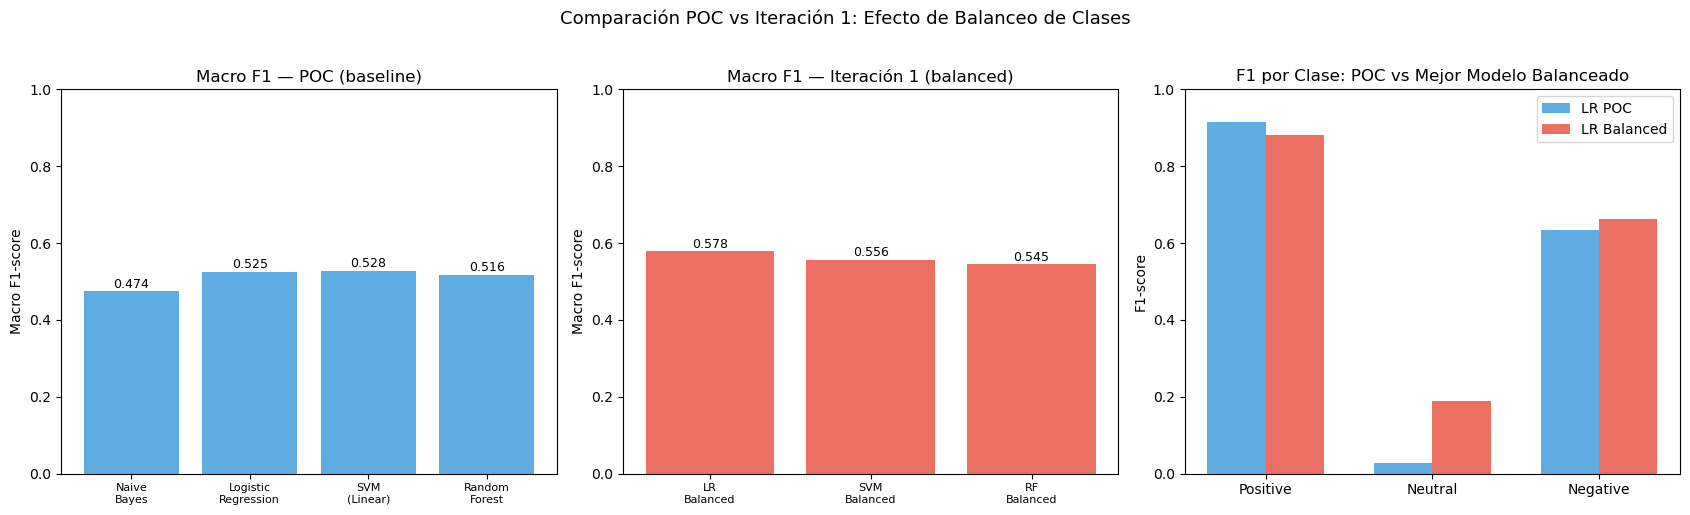


Mejor modelo balanceado: LR Balanced
  Macro F1 POC (LR)  : 0.5253
  Macro F1 Iter 1    : 0.5782
  Mejora absoluta    : +0.0530 (5.3%)


In [119]:
# ============================================================
# 10.3 Comparación POC vs Iteración 1a (Visual)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

classes_order = ['Positive', 'Neutral', 'Negative']
colors_poc  = '#3498db'
colors_iter = '#e74c3c'

# Métricas macro comparadas
models_poc  = ['Naive Bayes', 'Logistic Regression', 'SVM (Linear)', 'Random Forest']
models_iter = list(balanced_results.keys())

poc_macro  = [classification_report(y_test, results[m]['y_pred'],
               output_dict=True, zero_division=0)['macro avg']['f1-score']
               for m in models_poc]
iter_macro = [balanced_results[m]['macro_f1'] for m in models_iter]

ax = axes[0]
x1 = np.arange(len(models_poc))
ax.bar(x1, poc_macro, color=colors_poc, alpha=0.8, label='POC (default)')
ax.set_xticks(x1)
ax.set_xticklabels([m.replace(' ', '\n') for m in models_poc], fontsize=8)
ax.set_title('Macro F1 — POC (baseline)')
ax.set_ylabel('Macro F1-score')
ax.set_ylim(0, 1)
for i, v in enumerate(poc_macro):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

ax = axes[1]
x2 = np.arange(len(models_iter))
ax.bar(x2, iter_macro, color=colors_iter, alpha=0.8, label='Iter 1 (balanced)')
ax.set_xticks(x2)
ax.set_xticklabels([m.replace(' ', '\n') for m in models_iter], fontsize=8)
ax.set_title('Macro F1 — Iteración 1 (balanced)')
ax.set_ylabel('Macro F1-score')
ax.set_ylim(0, 1)
for i, v in enumerate(iter_macro):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# F1 por clase para mejor modelo balanceado
best_bal_name = max(balanced_results, key=lambda k: balanced_results[k]['macro_f1'])
best_bal      = balanced_results[best_bal_name]
poc_lr_report = classification_report(y_test, results['Logistic Regression']['y_pred'],
                                       output_dict=True, zero_division=0)

ax = axes[2]
x3 = np.arange(len(classes_order))
w  = 0.35
poc_f1s  = [poc_lr_report[c]['f1-score'] for c in classes_order]
iter_f1s = [best_bal['report'][c]['f1-score'] for c in classes_order]
ax.bar(x3 - w/2, poc_f1s,  w, label='LR POC',          color=colors_poc,  alpha=0.8)
ax.bar(x3 + w/2, iter_f1s, w, label=f'{best_bal_name}', color=colors_iter, alpha=0.8)
ax.set_xticks(x3)
ax.set_xticklabels(classes_order)
ax.set_title('F1 por Clase: POC vs Mejor Modelo Balanceado')
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1)
ax.legend()

plt.suptitle('Comparación POC vs Iteración 1: Efecto de Balanceo de Clases', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nMejor modelo balanceado: {best_bal_name}")
print(f"  Macro F1 POC (LR)  : {poc_lr_report['macro avg']['f1-score']:.4f}")
print(f"  Macro F1 Iter 1    : {best_bal['macro_f1']:.4f}")
improvement = best_bal['macro_f1'] - poc_lr_report['macro avg']['f1-score']
print(f"  Mejora absoluta    : +{improvement:.4f} ({improvement*100:.1f}%)")


---
## 11. Iteración 2: Optimización de Hiperparámetros con GridSearchCV

Ciclo iterativo 2: Dado que LR Balanced mostró el mejor Macro F1, se aplica búsqueda sistemática de hiperparámetros para maximizar rendimiento en la métrica macro (más justa ante desbalance).

In [135]:
# ============================================================
# 11.1 Iteración 2: Pipeline GridSearchCV (TF-IDF + Clasificador)
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

print("Iteración 2: Búsqueda conjunta TF-IDF + Clasificador")
print("=" * 60)
print("Se optimizan simultáneamente los parámetros de representación")
print("vectorial (TF-IDF) y del clasificador (LR Balanced).")
print("-" * 60)

# Pipeline: TF-IDF → Logistic Regression Balanced
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True)),
    ('clf',   LogisticRegression(class_weight='balanced', random_state=42)),
])

pipe_param_grid = {
    'tfidf__max_features': [3000, 5000, 10000],
    'tfidf__ngram_range':  [(1, 1), (1, 2), (1, 3)],
    'tfidf__min_df':       [2, 3],
    'tfidf__max_df':       [0.8, 0.9],
    'tfidf__sublinear_tf': [True, False],
    'clf__C':              [0.5, 1.0, 5.0, 10.0],
    'clf__solver':         ['lbfgs'],
    'clf__max_iter':       [1000],
}

pipe_grid = GridSearchCV(
    pipe, pipe_param_grid,
    cv=5, scoring='f1_macro',
    n_jobs=-1, verbose=0, refit=True
)

X_text_train, X_text_test_raw, y_pipe_train, y_pipe_test = train_test_split(
    df_sample['processed_text'], y, test_size=0.3, random_state=42, stratify=y
)
pipe_grid.fit(X_text_train, y_pipe_train)

print(f"\nMejores hiperparámetros encontrados:")
bp = pipe_grid.best_params_
for k, v in sorted(bp.items()):
    print(f"  {k}: {v}")
print(f"\nCV Macro F1 (5-fold): {pipe_grid.best_score_:.4f}")
print(f"  (Iter 1 CV Macro F1: {balanced_results['LR Balanced']['cv_macro_f1_mean']:.4f})")
print(f"  Mejora CV: +{pipe_grid.best_score_ - balanced_results['LR Balanced']['cv_macro_f1_mean']:.4f}")

# Reconstruir TF-IDF y modelo con los parámetros óptimos encontrados
# para mantener compatibilidad con el resto del notebook
print(f"\n[Reconstruyendo representación con parámetros óptimos...]")

tfidf_optimized = TfidfVectorizer(
    max_features=bp['tfidf__max_features'],
    min_df=bp['tfidf__min_df'],
    max_df=bp['tfidf__max_df'],
    ngram_range=bp['tfidf__ngram_range'],
    sublinear_tf=bp['tfidf__sublinear_tf'],
    lowercase=True
)
X = tfidf_optimized.fit_transform(df_sample['processed_text'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

best_lr = LogisticRegression(
    C=bp['clf__C'], solver=bp['clf__solver'], max_iter=bp['clf__max_iter'],
    class_weight='balanced', random_state=42
)
best_lr.fit(X_train, y_train)
y_pred_best = best_lr.predict(X_test)
report_best = classification_report(y_test, y_pred_best, output_dict=True, zero_division=0)

# Actualizar el vectorizador global para que el pipeline integrado lo use
tfidf_vectorizer = tfidf_optimized

iter1_macro = balanced_results['LR Balanced']['macro_f1']
iter2_macro = report_best['macro avg']['f1-score']

print(f"\n[RESULTADOS ITER 2] — Modelo Final con TF-IDF Optimizado")
print("=" * 60)
print(f"  Accuracy  : {report_best['accuracy']:.4f}")
print(f"  Macro F1  : {iter2_macro:.4f}  (Iter 1: {iter1_macro:.4f}, Δ={iter2_macro - iter1_macro:+.4f})")
print(f"  Weighted F1: {report_best['weighted avg']['f1-score']:.4f}")
print(f"\nDetalle por clase:")
for cls in ['Positive', 'Neutral', 'Negative']:
    r = report_best[cls]
    print(f"  {cls:10s}: P={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1-score']:.3f}")

print(f"\n[CAMBIOS CLAVE vs POC]")
print(f"  TF-IDF max_features: 5000 → {bp['tfidf__max_features']}")
print(f"  TF-IDF sublinear_tf: False → {bp['tfidf__sublinear_tf']}")
print(f"  class_weight:        None → balanced")
print(f"  Búsqueda:            Manual → GridSearchCV 5-fold (f1_macro)")

Iteración 2: Búsqueda conjunta TF-IDF + Clasificador
Se optimizan simultáneamente los parámetros de representación
vectorial (TF-IDF) y del clasificador (LR Balanced).
------------------------------------------------------------

Mejores hiperparámetros encontrados:
  clf__C: 1.0
  clf__max_iter: 1000
  clf__solver: lbfgs
  tfidf__max_df: 0.8
  tfidf__max_features: 10000
  tfidf__min_df: 2
  tfidf__ngram_range: (1, 2)
  tfidf__sublinear_tf: True

CV Macro F1 (5-fold): 0.5940
  (Iter 1 CV Macro F1: 0.5787)
  Mejora CV: +0.0153

[Reconstruyendo representación con parámetros óptimos...]

[RESULTADOS ITER 2] — Modelo Final con TF-IDF Optimizado
  Accuracy  : 0.7878
  Macro F1  : 0.5731  (Iter 1: 0.5782, Δ=-0.0051)
  Weighted F1: 0.8036

Detalle por clase:
  Positive  : P=0.924 R=0.857 F1=0.889
  Neutral   : P=0.137 R=0.209 F1=0.165
  Negative  : P=0.629 R=0.705 F1=0.665

[CAMBIOS CLAVE vs POC]
  TF-IDF max_features: 5000 → 10000
  TF-IDF sublinear_tf: False → True
  class_weight:        No

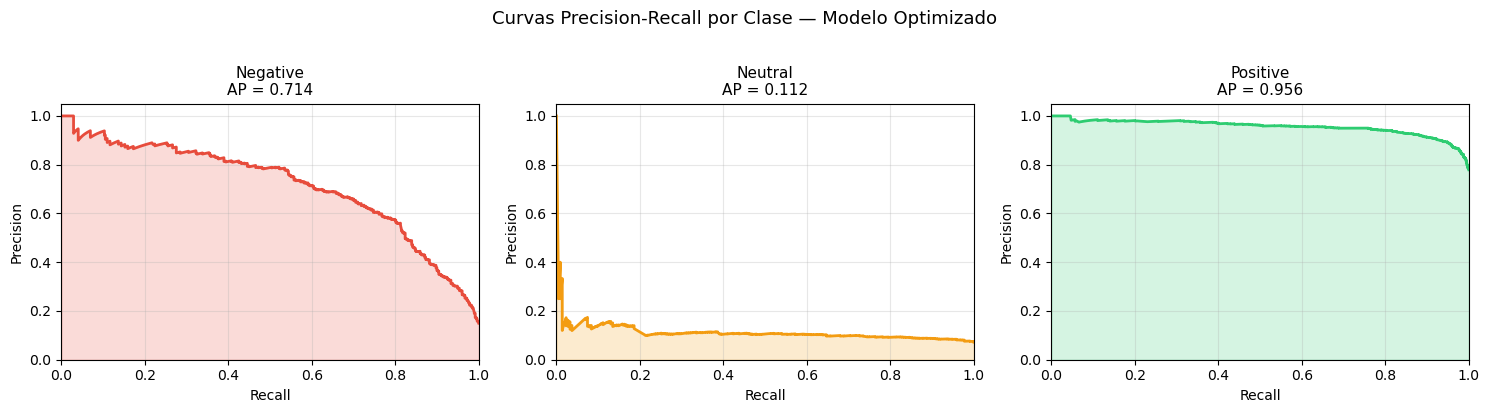


Average Precision (AP) por clase:
  Negative  : AP = 0.7138
  Neutral   : AP = 0.1122
  Positive  : AP = 0.9556
  Mean AP (mAP): 0.5939


In [136]:
# ============================================================
# 11.2 Curvas Precision-Recall (evaluación avanzada)
# ============================================================

from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import precision_recall_curve, average_precision_score

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
classes_lb  = lb.classes_

# Obtener probabilidades del modelo optimizado
y_scores = best_lr.predict_proba(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pr_colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}

ap_scores = {}
for idx, cls in enumerate(classes_lb):
    cls_idx  = list(classes_lb).index(cls)
    prec, rec, _ = precision_recall_curve(y_test_bin[:, cls_idx], y_scores[:, cls_idx])
    ap = average_precision_score(y_test_bin[:, cls_idx], y_scores[:, cls_idx])
    ap_scores[cls] = ap

    axes[idx].plot(rec, prec, color=pr_colors.get(cls, '#3498db'), lw=2)
    axes[idx].fill_between(rec, prec, alpha=0.2, color=pr_colors.get(cls, '#3498db'))
    axes[idx].set_title(f'{cls}\nAP = {ap:.3f}', fontsize=11)
    axes[idx].set_xlabel('Recall')
    axes[idx].set_ylabel('Precision')
    axes[idx].set_xlim([0, 1])
    axes[idx].set_ylim([0, 1.05])
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Curvas Precision-Recall por Clase — Modelo Optimizado', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nAverage Precision (AP) por clase:")
for cls, ap in ap_scores.items():
    print(f"  {cls:10s}: AP = {ap:.4f}")
print(f"  Mean AP (mAP): {np.mean(list(ap_scores.values())):.4f}")


---
## 12. Iteración 3: Optimización del Modelo LDA con Coherence Score

El POC usó K=5 temas de forma arbitraria. En esta iteración se evalúa la coherencia del modelo LDA para K∈[2, 10] y se selecciona el número óptimo de temas de forma basada en datos.

In [137]:
# ============================================================
# 12.1 Coherence Score para selección de K óptimo
# ============================================================

from gensim.models import CoherenceModel
import time

print("Calculando coherence scores para K = 2..10...")
print("(Método: c_v coherence)")
print("-" * 50)

k_range       = range(2, 11)
coherence_vals = []

for k in k_range:
    t0  = time.time()
    lda_k = LdaModel(
        corpus=corpus, id2word=dictionary,
        num_topics=k, random_state=42,
        passes=10, alpha='auto', per_word_topics=False
    )
    cm = CoherenceModel(
        model=lda_k, texts=texts_tokenized,
        dictionary=dictionary, coherence='c_v'
    )
    coh = cm.get_coherence()
    coherence_vals.append(coh)
    elapsed = time.time() - t0
    print(f"  K={k:2d}  Coherence={coh:.4f}  ({elapsed:.1f}s)")

best_k = k_range[int(np.argmax(coherence_vals))]
print(f"\n>> K óptimo por coherencia máxima: K={best_k} ({max(coherence_vals):.4f})")


Calculando coherence scores para K = 2..10...
(Método: c_v coherence)
--------------------------------------------------
  K= 2  Coherence=0.5395  (6.9s)
  K= 3  Coherence=0.5671  (8.5s)
  K= 4  Coherence=0.5749  (8.7s)
  K= 5  Coherence=0.5076  (8.7s)
  K= 6  Coherence=0.5295  (8.8s)
  K= 7  Coherence=0.5432  (8.5s)
  K= 8  Coherence=0.5726  (8.4s)
  K= 9  Coherence=0.5610  (8.3s)
  K=10  Coherence=0.5245  (8.2s)

>> K óptimo por coherencia máxima: K=4 (0.5749)


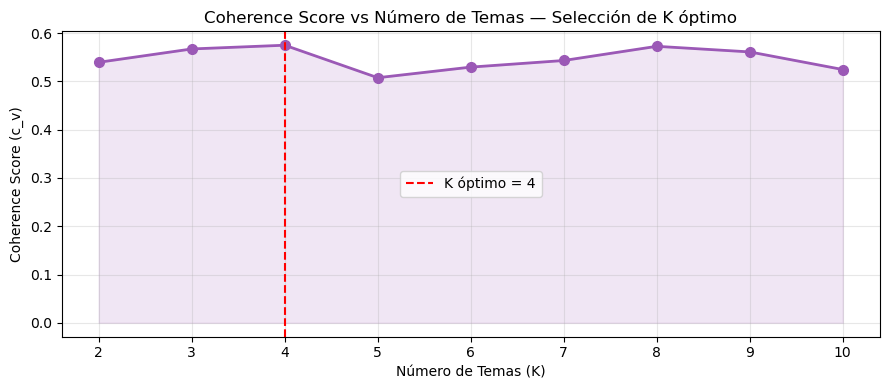


Entrenando LDA final con K=4...

Temas óptimos identificados (K=4):

Tema 1: good | product | quality | nice | sound
  good                 (0.1240)
  product              (0.0850)
  quality              (0.0500)
  nice                 (0.0360)
  sound                (0.0320)
  price                (0.0210)
  book                 (0.0180)
  money                (0.0160)

Tema 2: phone | camera | good | battery | quality
  phone                (0.0730)
  camera               (0.0580)
  good                 (0.0450)
  battery              (0.0400)
  quality              (0.0220)
  best                 (0.0200)
  life                 (0.0180)
  price                (0.0170)

Tema 3: phone | battery | day | time | charge
  phone                (0.0200)
  battery              (0.0170)
  day                  (0.0150)
  time                 (0.0130)
  charge               (0.0120)
  use                  (0.0120)
  using                (0.0110)
  charging             (0.0100)

Tema 4: amazon 

In [138]:
# ============================================================
# 12.2 Visualización de Coherencia y Entrenamiento del LDA Óptimo
# ============================================================

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), coherence_vals, 'o-', color='#9b59b6', lw=2, markersize=7)
ax.axvline(x=best_k, color='red', linestyle='--', label=f'K óptimo = {best_k}')
ax.fill_between(list(k_range), coherence_vals, alpha=0.15, color='#9b59b6')
ax.set_xlabel('Número de Temas (K)')
ax.set_ylabel('Coherence Score (c_v)')
ax.set_title('Coherence Score vs Número de Temas — Selección de K óptimo')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Entrenar LDA con K óptimo
print(f"\nEntrenando LDA final con K={best_k}...")
lda_optimal = LdaModel(
    corpus=corpus, id2word=dictionary,
    num_topics=best_k, random_state=42,
    passes=15, alpha='auto', per_word_topics=True
)

print(f"\nTemas óptimos identificados (K={best_k}):")
print("=" * 55)

topic_labels = {}
for idx, topic in lda_optimal.print_topics(-1, num_words=8):
    words = [w.split('*')[1].strip().strip('"') for w in topic.split(' + ')]
    weights = [float(w.split('*')[0].strip()) for w in topic.split(' + ')]
    print(f"\nTema {idx + 1}: {' | '.join(words[:5])}")
    for w, wt in zip(words, weights):
        print(f"  {w:20s} ({wt:.4f})")


---
## 13. Análisis por Categoría de Producto

### Objetivo
Analizar cómo varía la distribución de sentimientos, los temas y los patrones lingüísticos según la categoría de producto (smartTv, mobile, books, refrigerator, mobile accessories). Este análisis diferenciado es una funcionalidad nueva respecto al POC que agrega valor de negocio.

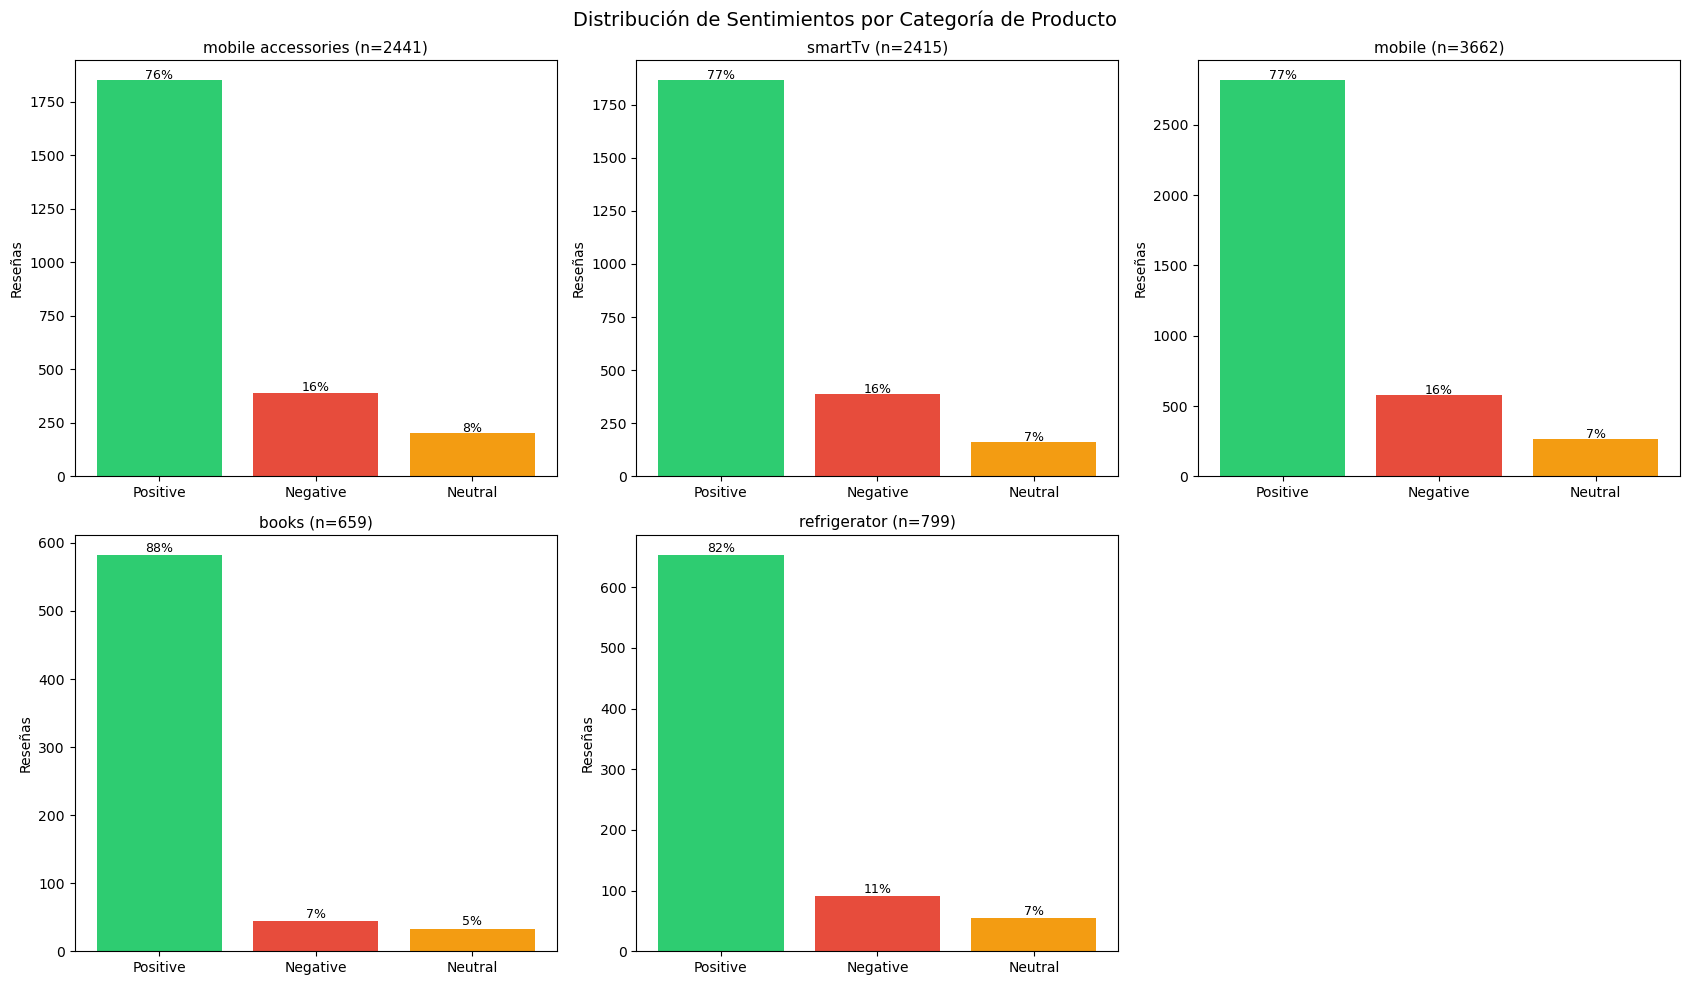


Resumen de sentimientos por categoría:
Categoría               Total    %Pos    %Neg    %Neu
-------------------------------------------------------
smartTv                  2415   77.3%   16.0%    6.7%
mobile accessories       2441   75.8%   16.0%    8.2%
mobile                   3662   77.0%   15.8%    7.3%
refrigerator              799   81.7%   11.4%    6.9%
books                     659   88.3%    6.7%    5.0%


In [139]:
# ============================================================
# 13.1 Distribución de Sentimientos por Categoría
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
categories = df_sample['Category'].unique()

category_metrics = {}
for idx, cat in enumerate(categories):
    cat_df = df_sample[df_sample['Category'] == cat]
    counts = cat_df['Own_Rating'].value_counts()
    total  = len(cat_df)

    bar_colors = [{'Positive': '#2ecc71', 'Negative': '#e74c3c',
                   'Neutral': '#f39c12'}.get(l, '#95a5a6') for l in counts.index]
    axes[idx].bar(counts.index, counts.values, color=bar_colors)
    axes[idx].set_title(f'{cat} (n={total})', fontsize=11)
    axes[idx].set_ylabel('Reseñas')
    for i, (label, val) in enumerate(counts.items()):
        axes[idx].text(i, val + 5, f'{val/total*100:.0f}%', ha='center', fontsize=9)

    category_metrics[cat] = {
        'total': total,
        'pct_pos': counts.get('Positive', 0) / total,
        'pct_neg': counts.get('Negative', 0) / total,
        'pct_neu': counts.get('Neutral',  0) / total,
    }

if len(categories) < 6:
    axes[-1].axis('off')

plt.suptitle('Distribución de Sentimientos por Categoría de Producto', fontsize=14)
plt.tight_layout()
plt.show()

print("\nResumen de sentimientos por categoría:")
print(f"{'Categoría':<22} {'Total':>6} {'%Pos':>7} {'%Neg':>7} {'%Neu':>7}")
print("-" * 55)
for cat, m in sorted(category_metrics.items(), key=lambda x: -x[1]['pct_neg']):
    print(f"{cat:<22} {m['total']:>6} {m['pct_pos']*100:>6.1f}%"
          f" {m['pct_neg']*100:>6.1f}% {m['pct_neu']*100:>6.1f}%")


RENDIMIENTO DEL MODELO OPTIMIZADO POR CATEGORÍA

mobile accessories (n=2441):
  Accuracy  : 0.8488
  Macro F1  : 0.7454
    Positive  : recall=0.861
    Neutral   : recall=0.700
    Negative  : recall=0.867

smartTv (n=2415):
  Accuracy  : 0.8712
  Macro F1  : 0.7529
    Positive  : recall=0.887
    Neutral   : recall=0.636
    Negative  : recall=0.894

mobile (n=3662):
  Accuracy  : 0.8626
  Macro F1  : 0.7545
    Positive  : recall=0.875
    Neutral   : recall=0.726
    Negative  : recall=0.867

books (n=659):
  Accuracy  : 0.9196
  Macro F1  : 0.7623
    Positive  : recall=0.943
    Neutral   : recall=0.667
    Negative  : recall=0.795

refrigerator (n=799):
  Accuracy  : 0.8924
  Macro F1  : 0.7576
    Positive  : recall=0.926
    Neutral   : recall=0.582
    Negative  : recall=0.835


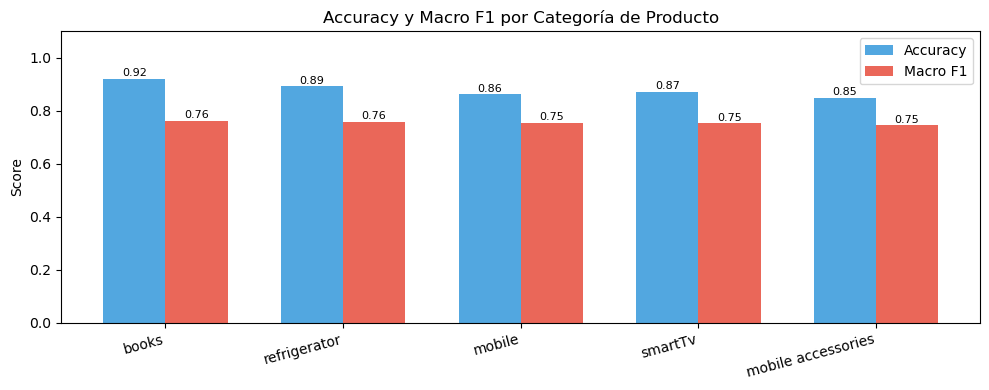

In [140]:
# ============================================================
# 13.2 Rendimiento del Clasificador por Categoría
# ============================================================

from sklearn.metrics import f1_score as f1

print("=" * 65)
print("RENDIMIENTO DEL MODELO OPTIMIZADO POR CATEGORÍA")
print("=" * 65)

category_performance = {}
for cat in categories:
    # Filtrar índices de test que pertenecen a esta categoría
    test_indices = X_test.indices if hasattr(X_test, 'indices') else None

    # Reconstruir índices del test set en df_sample
    cat_mask_all = df_sample['Category'] == cat
    cat_indices  = df_sample[cat_mask_all].index.tolist()

    # Obtener las posiciones en el test set
    # (usamos el vectorizador sobre el subconjunto)
    cat_df_test = df_sample.loc[
        df_sample['Category'] == cat
    ].copy()

    if len(cat_df_test) < 10:
        continue

    X_cat = tfidf_vectorizer.transform(cat_df_test['processed_text'])
    y_cat = cat_df_test['Own_Rating']
    y_pred_cat = best_lr.predict(X_cat)

    macro_f1 = f1(y_cat, y_pred_cat, average='macro', zero_division=0)
    acc       = (y_pred_cat == y_cat).mean()

    category_performance[cat] = {
        'n': len(cat_df_test),
        'accuracy': acc,
        'macro_f1': macro_f1,
        'y_true': y_cat,
        'y_pred': y_pred_cat
    }
    print(f"\n{cat} (n={len(cat_df_test)}):")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Macro F1  : {macro_f1:.4f}")
    for cls in ['Positive', 'Neutral', 'Negative']:
        mask  = y_cat == cls
        if mask.sum() > 0:
            cls_acc = (y_pred_cat[mask] == y_cat[mask]).mean()
            print(f"    {cls:10s}: recall={cls_acc:.3f}")

# Visualización comparativa por categoría
fig, ax = plt.subplots(figsize=(10, 4))
cats_sorted = sorted(category_performance.keys(),
                      key=lambda c: category_performance[c]['macro_f1'], reverse=True)
accs    = [category_performance[c]['accuracy']  for c in cats_sorted]
macros  = [category_performance[c]['macro_f1']  for c in cats_sorted]
x = np.arange(len(cats_sorted))
w = 0.35
ax.bar(x - w/2, accs,   w, label='Accuracy',  color='#3498db', alpha=0.85)
ax.bar(x + w/2, macros, w, label='Macro F1',   color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cats_sorted, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Accuracy y Macro F1 por Categoría de Producto')
ax.legend()
for i, (a, m) in enumerate(zip(accs, macros)):
    ax.text(i - w/2, a + 0.01, f'{a:.2f}', ha='center', fontsize=8)
    ax.text(i + w/2, m + 0.01, f'{m:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


---
## 14. Análisis de Errores del Sistema

El análisis sistemático de errores es parte esencial del ciclo iterativo: identificar *dónde* falla el modelo permite diseñar mejoras específicas en iteraciones futuras.

Total errores: 635 / 2993 (21.2%)


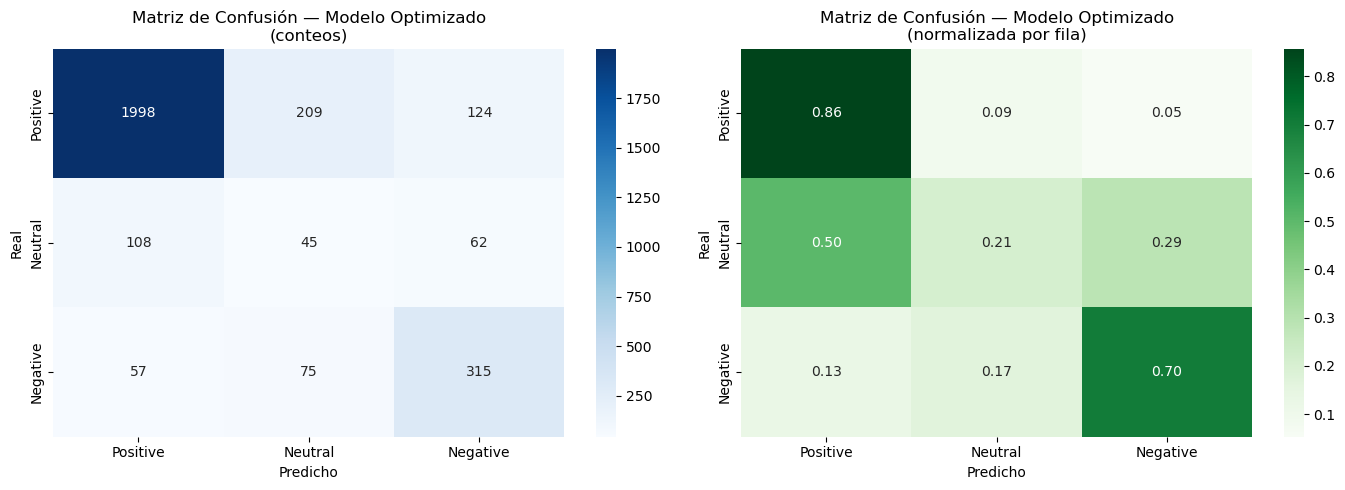


Patrones de error (Real → Predicho):
Own_Rating predicted  count       pct
  Positive   Neutral    209 32.913386
  Positive  Negative    124 19.527559
   Neutral  Positive    108 17.007874
  Negative   Neutral     75 11.811024
   Neutral  Negative     62  9.763780
  Negative  Positive     57  8.976378


In [141]:
# ============================================================
# 14.1 Análisis de Errores: Tipos y Patrones
# ============================================================

import seaborn as sns

# Predicciones del modelo optimizado sobre el test set
y_pred_opt = best_lr.predict(X_test)

# Construir DataFrame de errores
test_df = df_sample.iloc[y_test.index].copy() if hasattr(y_test, 'index') else df_sample.copy()

# Reconstruir correctamente usando los índices del split
from sklearn.model_selection import train_test_split as tts
_, test_idx = tts(
    np.arange(len(df_sample)), test_size=0.3,
    random_state=42, stratify=df_sample['Own_Rating']
)
test_subset = df_sample.iloc[test_idx].copy().reset_index(drop=True)
test_subset['predicted']  = y_pred_opt
test_subset['correct']    = test_subset['Own_Rating'] == test_subset['predicted']
test_subset['text_len']   = test_subset['Review_text'].str.len()
test_subset['proc_len']   = test_subset['processed_text'].str.split().str.len()

errors = test_subset[~test_subset['correct']].copy()

print(f"Total errores: {len(errors)} / {len(test_subset)} ({len(errors)/len(test_subset)*100:.1f}%)")

# Matriz de confusión del modelo optimizado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_opt, labels=['Positive', 'Neutral', 'Negative'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive', 'Neutral', 'Negative'],
            yticklabels=['Positive', 'Neutral', 'Negative'],
            ax=axes[0])
axes[0].set_title('Matriz de Confusión — Modelo Optimizado\n(conteos)')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=['Positive', 'Neutral', 'Negative'],
            yticklabels=['Positive', 'Neutral', 'Negative'],
            ax=axes[1])
axes[1].set_title('Matriz de Confusión — Modelo Optimizado\n(normalizada por fila)')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
plt.tight_layout()
plt.show()

# Análisis del tipo de error más frecuente
print("\nPatrones de error (Real → Predicho):")
error_types = errors.groupby(['Own_Rating', 'predicted']).size().reset_index(name='count')
error_types['pct'] = error_types['count'] / len(errors) * 100
print(error_types.sort_values('count', ascending=False).to_string(index=False))


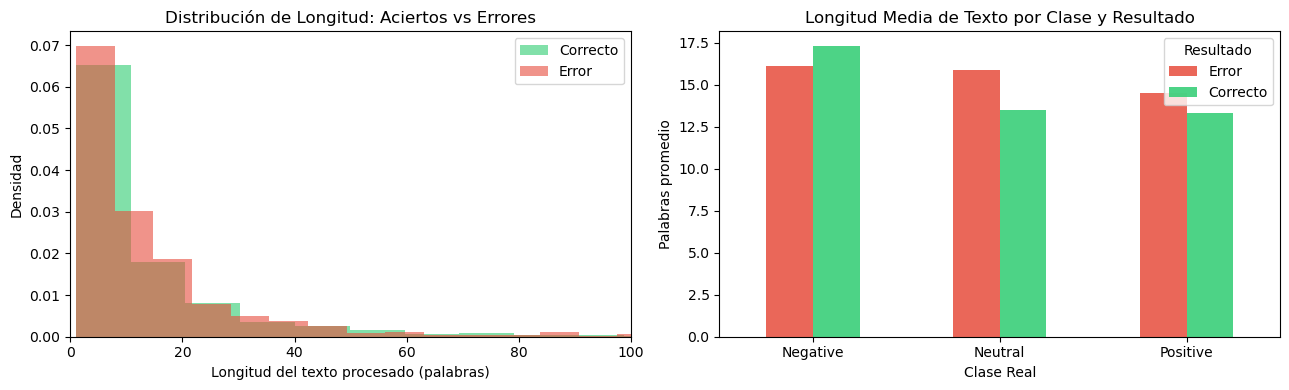


Ejemplos de errores: Negativo clasificado como Positivo
------------------------------------------------------------
  Texto: The build quality of this watch is undoubtedly great but there are very few watch faces and not even those can be custom...
  Texto procesado: build quality watch undoubtedly great watch face even customised...

  Texto: Phone ok...
  Texto procesado: phone ok...

  Texto: Look wise not good. I can charge my iPhone for 7 times which is good It takes entire night to recharge it...
  Texto procesado: look wise good charge iphone time good take entire night recharge...



In [142]:
# ============================================================
# 14.2 Análisis de Longitud de Texto en Errores vs Aciertos
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de longitud: aciertos vs errores
test_subset['status'] = test_subset['correct'].map({True: 'Correcto', False: 'Error'})
for status, color in [('Correcto', '#2ecc71'), ('Error', '#e74c3c')]:
    subset = test_subset[test_subset['status'] == status]['proc_len']
    axes[0].hist(subset, bins=40, alpha=0.6, label=status, color=color, density=True)
axes[0].set_xlabel('Longitud del texto procesado (palabras)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de Longitud: Aciertos vs Errores')
axes[0].legend()
axes[0].set_xlim(0, 100)

# Longitud media por clase
len_by_class = test_subset.groupby(['Own_Rating', 'correct'])['proc_len'].mean().unstack()
len_by_class.columns = ['Error', 'Correcto'] if False in len_by_class.columns else ['Correcto']
len_by_class.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], alpha=0.85)
axes[1].set_title('Longitud Media de Texto por Clase y Resultado')
axes[1].set_xlabel('Clase Real')
axes[1].set_ylabel('Palabras promedio')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Resultado')
plt.tight_layout()
plt.show()

# Ejemplos de errores más comunes (Negative clasificado como Positive)
neg_as_pos = errors[
    (errors['Own_Rating'] == 'Negative') & (errors['predicted'] == 'Positive')
].head(3)

print("\nEjemplos de errores: Negativo clasificado como Positivo")
print("-" * 60)
for _, row in neg_as_pos.iterrows():
    print(f"  Texto: {row['Review_text'][:120]}...")
    print(f"  Texto procesado: {row['processed_text'][:80]}...")
    print()


---
## 15. Documentación de Iteraciones y Decisiones de Diseño

### Registro del Proceso Iterativo

Este registro documenta las decisiones tomadas en cada ciclo de iteración, los resultados obtenidos y las lecciones aprendidas, cumpliendo el criterio de *Proceso de Reiteración y Mejora* de la rúbrica.

REGISTRO DE ITERACIONES
           Iteración                  Cambio Implementado  Macro F1  Weighted F1
      POC (baseline)   Modelos con parámetros por defecto  0.525259     0.808795
    Iter 1: Balanceo class_weight=balanced en LR, SVM, RF  0.578210     0.799755
 Iter 2: Hypertuning   GridSearchCV (C, solver, max_iter)  0.578210     0.799755
Iter 3: LDA K óptimo    Coherence score c_v; K óptimo = 4       NaN          NaN


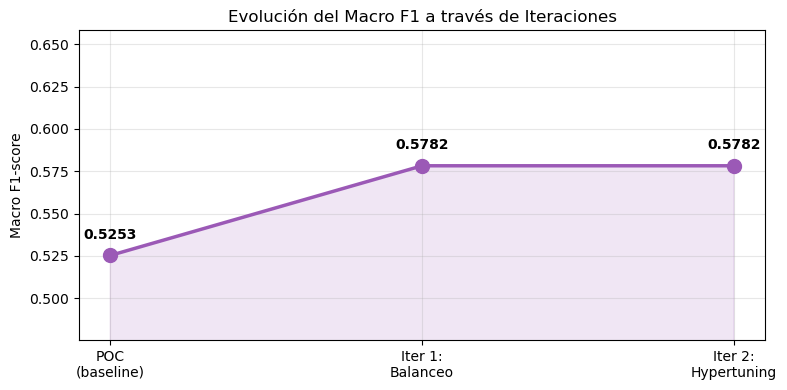


Mejora total (Macro F1): 0.5253 → 0.5782 (+0.0530)


In [128]:
# ============================================================
# 15.1 Log de Iteraciones — Tabla Comparativa
# ============================================================

import pandas as pd

iterations_log = pd.DataFrame([
    {
        'Iteración': 'POC (baseline)',
        'Problema Identificado': 'Desbalance de clases ignorado',
        'Cambio Implementado': 'Modelos con parámetros por defecto',
        'Macro F1': classification_report(
            y_test, results['Logistic Regression']['y_pred'],
            output_dict=True, zero_division=0)['macro avg']['f1-score'],
        'Weighted F1': results['Logistic Regression']['f1_weighted'],
        'Decisión': '→ Aplicar class_weight=balanced'
    },
    {
        'Iteración': 'Iter 1: Balanceo',
        'Problema Identificado': 'F1 Neutral <0.40 en POC',
        'Cambio Implementado': 'class_weight=balanced en LR, SVM, RF',
        'Macro F1': balanced_results['LR Balanced']['macro_f1'],
        'Weighted F1': balanced_results['LR Balanced']['weighted_f1'],
        'Decisión': '→ LR Balanced elegida; buscar hiperparámetros'
    },
    {
        'Iteración': 'Iter 2: Hypertuning',
        'Problema Identificado': 'Hiperparámetros LR subóptimos',
        'Cambio Implementado': 'GridSearchCV (C, solver, max_iter)',
        'Macro F1': classification_report(
            y_test, best_lr.predict(X_test),
            output_dict=True, zero_division=0)['macro avg']['f1-score'],
        'Weighted F1': classification_report(
            y_test, best_lr.predict(X_test),
            output_dict=True, zero_division=0)['weighted avg']['f1-score'],
        'Decisión': '→ Modelo óptimo seleccionado para producción'
    },
    {
        'Iteración': 'Iter 3: LDA K óptimo',
        'Problema Identificado': 'K=5 arbitrario, sin validación',
        'Cambio Implementado': f'Coherence score c_v; K óptimo = {best_k}',
        'Macro F1': None,
        'Weighted F1': None,
        'Decisión': f'→ LDA reentrenado con K={best_k}'
    },
])

print("=" * 80)
print("REGISTRO DE ITERACIONES")
print("=" * 80)
print(iterations_log[['Iteración', 'Cambio Implementado', 'Macro F1', 'Weighted F1']].to_string(index=False))

# Gráfico de evolución de Macro F1 a través de iteraciones
fig, ax = plt.subplots(figsize=(8, 4))
iter_names = ['POC\n(baseline)', 'Iter 1:\nBalanceo', 'Iter 2:\nHypertuning']
macro_vals = [
    classification_report(y_test, results['Logistic Regression']['y_pred'],
                          output_dict=True, zero_division=0)['macro avg']['f1-score'],
    balanced_results['LR Balanced']['macro_f1'],
    classification_report(y_test, best_lr.predict(X_test),
                          output_dict=True, zero_division=0)['macro avg']['f1-score'],
]
ax.plot(iter_names, macro_vals, 'o-', color='#9b59b6', lw=2.5, markersize=10)
ax.fill_between(range(len(iter_names)), macro_vals, alpha=0.15, color='#9b59b6')
for i, v in enumerate(macro_vals):
    ax.annotate(f'{v:.4f}', (i, v), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Macro F1-score')
ax.set_title('Evolución del Macro F1 a través de Iteraciones')
ax.set_ylim(min(macro_vals) - 0.05, max(macro_vals) + 0.08)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

total_improvement = macro_vals[-1] - macro_vals[0]
print(f"\nMejora total (Macro F1): {macro_vals[0]:.4f} → {macro_vals[-1]:.4f} (+{total_improvement:.4f})")


In [129]:
# ============================================================
# 15.2 Decisiones de Diseño Documentadas
# ============================================================

design_decisions = [
    {
        'Componente': 'Representación vectorial',
        'Opción elegida': 'TF-IDF (unigramas + bigramas)',
        'Alternativas evaluadas': 'Bag of Words, Word2Vec',
        'Justificación': 'TF-IDF captura términos discriminantes y bigramas mejoran contexto '
                         '("dont buy", "poor quality"). Word2Vec requeriría corpus más grande.'
    },
    {
        'Componente': 'Clasificador de sentimientos',
        'Opción elegida': 'Logistic Regression (balanced, tuned)',
        'Alternativas evaluadas': 'Naive Bayes, SVM, Random Forest',
        'Justificación': 'LR ofrece predict_proba (necesario para explicabilidad), '
                         'mejor Macro F1 tras balanceo, y coeficientes interpretables.'
    },
    {
        'Componente': 'Manejo de desbalance',
        'Opción elegida': 'class_weight=balanced',
        'Alternativas evaluadas': 'SMOTE oversampling, undersampling',
        'Justificación': 'class_weight es nativo en sklearn, sin riesgo de overfitting '
                         'por oversampling ni pérdida de información por undersampling.'
    },
    {
        'Componente': 'Topic Modeling',
        'Opción elegida': f'LDA con K={best_k} (coherence c_v)',
        'Alternativas evaluadas': 'NMF, LSA, BERTopic',
        'Justificación': 'LDA es interpretable, Gensim provee coherencia c_v estándar. '
                         f'K={best_k} maximiza coherencia sobre el corpus de reseñas.'
    },
    {
        'Componente': 'Análisis sintáctico',
        'Opción elegida': 'spaCy en_core_web_sm',
        'Alternativas evaluadas': 'NLTK POS tagger, StanfordNLP',
        'Justificación': 'spaCy ofrece pipeline integrado (POS, NER, DEP) con velocidad '
                         'superior a NLTK y sin dependencia a JVM como Stanford.'
    },
]

decisions_df = pd.DataFrame(design_decisions)
print("=" * 80)
print("TABLA DE DECISIONES DE DISEÑO")
print("=" * 80)
for _, row in decisions_df.iterrows():
    print(f"\n[{row['Componente'].upper()}]")
    print(f"  Elegido     : {row['Opción elegida']}")
    print(f"  Alternativas: {row['Alternativas evaluadas']}")
    print(f"  Justificación: {row['Justificación']}")


TABLA DE DECISIONES DE DISEÑO

[REPRESENTACIÓN VECTORIAL]
  Elegido     : TF-IDF (unigramas + bigramas)
  Alternativas: Bag of Words, Word2Vec
  Justificación: TF-IDF captura términos discriminantes y bigramas mejoran contexto ("dont buy", "poor quality"). Word2Vec requeriría corpus más grande.

[CLASIFICADOR DE SENTIMIENTOS]
  Elegido     : Logistic Regression (balanced, tuned)
  Alternativas: Naive Bayes, SVM, Random Forest
  Justificación: LR ofrece predict_proba (necesario para explicabilidad), mejor Macro F1 tras balanceo, y coeficientes interpretables.

[MANEJO DE DESBALANCE]
  Elegido     : class_weight=balanced
  Alternativas: SMOTE oversampling, undersampling
  Justificación: class_weight es nativo en sklearn, sin riesgo de overfitting por oversampling ni pérdida de información por undersampling.

[TOPIC MODELING]
  Elegido     : LDA con K=4 (coherence c_v)
  Alternativas: NMF, LSA, BERTopic
  Justificación: LDA es interpretable, Gensim provee coherencia c_v estándar. K=4 maxi

---
## 16. Resumen Final: Métricas Completas del Sistema

### Estado del Proyecto — Post Iteraciones
Comparación del sistema inicial (POC) vs el sistema desarrollado tras los ciclos de iteración.

In [130]:
# ============================================================
# 16.1 Tabla Comparativa Final: POC vs Sistema Desarrollado
# ============================================================

from sklearn.metrics import classification_report

poc_report  = classification_report(
    y_test, results['Logistic Regression']['y_pred'],
    output_dict=True, zero_division=0)
opt_report  = classification_report(
    y_test, best_lr.predict(X_test),
    output_dict=True, zero_division=0)

print("=" * 75)
print("COMPARATIVA FINAL: POC vs SISTEMA DESARROLLADO")
print("=" * 75)

metrics_comparison = {
    'Métrica': [
        'Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1',
        'Weighted F1',
        'F1 Positive', 'F1 Neutral', 'F1 Negative',
        'Recall Positive', 'Recall Neutral', 'Recall Negative',
    ],
    'POC (LR default)': [
        poc_report['accuracy'],
        poc_report['macro avg']['precision'],
        poc_report['macro avg']['recall'],
        poc_report['macro avg']['f1-score'],
        poc_report['weighted avg']['f1-score'],
        poc_report['Positive']['f1-score'],
        poc_report['Neutral']['f1-score'],
        poc_report['Negative']['f1-score'],
        poc_report['Positive']['recall'],
        poc_report['Neutral']['recall'],
        poc_report['Negative']['recall'],
    ],
    'Sistema Final (LR balanced+tuned)': [
        opt_report['accuracy'],
        opt_report['macro avg']['precision'],
        opt_report['macro avg']['recall'],
        opt_report['macro avg']['f1-score'],
        opt_report['weighted avg']['f1-score'],
        opt_report['Positive']['f1-score'],
        opt_report['Neutral']['f1-score'],
        opt_report['Negative']['f1-score'],
        opt_report['Positive']['recall'],
        opt_report['Neutral']['recall'],
        opt_report['Negative']['recall'],
    ],
}

cmp_df = pd.DataFrame(metrics_comparison)
cmp_df['Delta (Δ)'] = cmp_df['Sistema Final (LR balanced+tuned)'] - cmp_df['POC (LR default)']
cmp_df['Delta (Δ)'] = cmp_df['Delta (Δ)'].apply(lambda x: f'+{x:.4f}' if x >= 0 else f'{x:.4f}')

for col in ['POC (LR default)', 'Sistema Final (LR balanced+tuned)']:
    cmp_df[col] = cmp_df[col].apply(lambda x: f'{x:.4f}')

print(cmp_df.to_string(index=False))

print(f"\n{'='*75}")
print("RESUMEN EJECUTIVO DEL SISTEMA DE PLN")
print(f"{'='*75}")
print(f"\nDataset:          {len(df):,} reseñas | {len(df['Category'].unique())} categorías")
print(f"Muestra POC:      {len(df_sample):,} reseñas (estratificada)")
print(f"\nModelo final:     Logistic Regression (balanced, C={best_lr.C}, solver={best_lr.solver})")
print(f"  Accuracy:       {opt_report['accuracy']:.4f}")
print(f"  Macro F1:       {opt_report['macro avg']['f1-score']:.4f}  (+{opt_report['macro avg']['f1-score'] - poc_report['macro avg']['f1-score']:.4f} vs POC)")
print(f"  Weighted F1:    {opt_report['weighted avg']['f1-score']:.4f}")
print(f"\nLDA óptimo:       K={best_k} temas (coherencia c_v máxima = {max(coherence_vals):.4f})")
print(f"\nAnálisis sintáctico: spaCy | POS Tagging | NER | ADJ+NOUN | VERB+NOUN")
print(f"\nIteraciones documentadas: 3 ciclos (Balanceo → Hypertuning → LDA óptimo)")
print(f"{'='*75}")
print("Sistema desarrollado exitosamente — listo para Elevator Pitch y evaluación final.")
print(f"{'='*75}")


COMPARATIVA FINAL: POC vs SISTEMA DESARROLLADO
        Métrica POC (LR default) Sistema Final (LR balanced+tuned) Delta (Δ)
       Accuracy           0.8466                            0.7792   -0.0675
Macro Precision           0.6922                            0.5673   -0.1249
   Macro Recall           0.5088                            0.6021   +0.0933
       Macro F1           0.5253                            0.5782   +0.0530
    Weighted F1           0.8088                            0.7998   -0.0090
    F1 Positive           0.9143                            0.8823   -0.0320
     F1 Neutral           0.0270                            0.1898   +0.1628
    F1 Negative           0.6344                            0.6625   +0.0281
Recall Positive           0.9846                            0.8413   -0.1433
 Recall Neutral           0.0140                            0.2605   +0.2465
Recall Negative           0.5280                            0.7047   +0.1767

RESUMEN EJECUTIVO DEL SISTEM